In [1]:
!pip install shap
!pip install boruta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import xgboost as xgbimport
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from boruta import BorutaPy



# Load the data
df = pd.read_csv(
    'large_fires_data_v2_ndfb_kd_pr.csv',
    names= [
        'point_id',
        'lat_dd',
        'long_dd',
        'ndfb_kd_pr',
        'Aspect',
        'Climatic water deficit',
        'Elevation',
        'Humidity',
        'LULC',
        'NDVI',
        'Evaptranspiration',
        'Precipitation',
        'Slope',
        'Soil moisture',
        'Shortwave radiation flux',
        'Maximum Temperature',
        'Wind speed',
        'dist_fores',
        'human_foot',
        'tree_speci',
        'pdsi'
    ],
    header= 0
)

In [3]:
df.head()

,point_id,lat_dd,long_dd,ndfb_kd_pr,Aspect,Climatic water deficit,Elevation,Humidity,LULC,NDVI,...,Precipitation,Slope,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,dist_fores,human_foot,tree_speci,pdsi
0,158005,65.050550,-89.044667,0.000000,47,46.186600,269.617004,0.002247,8,0.079046,...,24.404200,1,14.1892,116.626999,-7.16408,5.30000,314.682007,0,0,-0.571167
1,130346,61.883883,-74.211333,0.000000,213,23.060200,296.898010,0.002579,8,0.094856,...,34.991600,2,25.7878,114.869003,-3.15483,4.63180,217.082993,0,0,-1.843460
2,183391,67.717217,-103.294667,0.000000,97,42.576302,45.762699,0.002338,3,0.116552,...,14.038700,0,15.5709,105.838997,-7.95486,5.36627,109.772003,0,0,-1.361040
3,176092,66.967217,-105.294667,0.000454,90,45.948200,219.136002,0.002431,3,0.157896,...,17.213301,0,25.2700,106.525002,-6.91958,4.99333,96.566002,0,0,-0.076833
4,125763,61.300550,-77.294667,0.000000,261,34.952599,151.550003,0.002692,3,0.136256,...,29.578301,0,26.3050,120.428001,-2.37533,5.00017,192.354004,0,0,0.105917


In [4]:
# Replace -9999 with NaN
df.replace(-9999, np.nan, inplace=True)

# Verify if replacement was successful by checking for null values
df.isnull().sum()

,0
point_id,0
lat_dd,0
long_dd,0
ndfb_kd_pr,0
Aspect,20
Climatic water deficit,70
Elevation,152
Humidity,114
LULC,100
NDVI,98


In [5]:
# Drop rows with NaN values
df.dropna(inplace=True)

In [6]:
replace_values_LULC = {
    1: 'Urban_areas',
    2: 'Crop_land',
    3: 'Grass_land',
    4: 'Tree_covered',
    5: 'Shrub_covered',
    6: 'Herbaceous',
    8: 'Sparse_vegetation',
    9: 'Bare_soil',
    10: 'Snow',
    11: 'Water_bodies',
}

df['LULC'] = df['LULC'].replace(replace_values_LULC)

In [7]:
df.head(10)

,point_id,lat_dd,long_dd,ndfb_kd_pr,Aspect,Climatic water deficit,Elevation,Humidity,LULC,NDVI,...,Precipitation,Slope,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,dist_fores,human_foot,tree_speci,pdsi
0,158005,65.050550,-89.044667,0.000000,47.0,46.186600,269.617004,0.002247,Sparse_vegetation,0.079046,...,24.404200,1.0,14.189200,116.626999,-7.16408,5.30000,314.682007,0.0,0.0,-0.571167
1,130346,61.883883,-74.211333,0.000000,213.0,23.060200,296.898010,0.002579,Sparse_vegetation,0.094856,...,34.991600,2.0,25.787800,114.869003,-3.15483,4.63180,217.082993,0.0,0.0,-1.843460
2,183391,67.717217,-103.294667,0.000000,97.0,42.576302,45.762699,0.002338,Grass_land,0.116552,...,14.038700,0.0,15.570900,105.838997,-7.95486,5.36627,109.772003,0.0,0.0,-1.361040
3,176092,66.967217,-105.294667,0.000454,90.0,45.948200,219.136002,0.002431,Grass_land,0.157896,...,17.213301,0.0,25.270000,106.525002,-6.91958,4.99333,96.566002,0.0,0.0,-0.076833
4,125763,61.300550,-77.294667,0.000000,261.0,34.952599,151.550003,0.002692,Grass_land,0.136256,...,29.578301,0.0,26.305000,120.428001,-2.37533,5.00017,192.354004,0.0,0.0,0.105917
5,125762,61.300550,-77.378000,0.000000,8.0,35.426300,116.688003,0.002710,Grass_land,0.125892,...,29.052300,0.0,26.796200,120.767998,-2.39621,5.16056,192.354004,0.0,0.0,0.143851
6,110972,59.383883,-73.544667,0.000000,108.0,30.247601,142.274002,0.002892,Grass_land,0.159960,...,35.616699,0.0,22.295799,121.200996,-1.00025,4.97250,10.000000,0.0,0.0,-1.163870
7,194692,69.217217,-83.211333,0.000000,58.0,21.908300,253.585007,0.001977,Sparse_vegetation,0.021816,...,19.538300,0.0,25.020800,109.987999,-9.35300,4.15350,385.032013,0.0,0.0,-1.673280
8,176136,66.967217,-101.628000,0.000005,122.0,46.581799,135.770004,0.002362,Grass_land,0.163414,...,14.529000,0.0,20.348400,108.818001,-7.95364,5.24031,223.270996,0.0,0.0,-1.760880
9,181892,67.550550,-96.544667,0.000000,111.0,44.187000,7.893100,0.002275,Sparse_vegetation,0.038806,...,12.822500,0.0,13.854999,108.843002,-8.23567,5.33125,370.000000,0.0,0.0,-2.269920


In [8]:
# Convert necessary columns to categorical
df = df.astype(
    {
        'LULC': 'category'
    }
)

In [9]:
# # Replace -9999 with NaN
# df.replace(-9999, np.nan, inplace= True)

# # Fill NaN values using forward and Backward fill
# df.fillna(method='ffill', inplace= True)
# df.fillna(method= 'bfill', inplace= True)

In [10]:
df

,point_id,lat_dd,long_dd,ndfb_kd_pr,Aspect,Climatic water deficit,Elevation,Humidity,LULC,NDVI,...,Precipitation,Slope,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,dist_fores,human_foot,tree_speci,pdsi
0,158005,65.050550,-89.044667,0.000000,47.0,46.186600,269.617004,0.002247,Sparse_vegetation,0.079046,...,24.404200,1.0,14.189200,116.626999,-7.164080,5.30000,314.682007,0.0,0.0,-0.571167
1,130346,61.883883,-74.211333,0.000000,213.0,23.060200,296.898010,0.002579,Sparse_vegetation,0.094856,...,34.991600,2.0,25.787800,114.869003,-3.154830,4.63180,217.082993,0.0,0.0,-1.843460
2,183391,67.717217,-103.294667,0.000000,97.0,42.576302,45.762699,0.002338,Grass_land,0.116552,...,14.038700,0.0,15.570900,105.838997,-7.954860,5.36627,109.772003,0.0,0.0,-1.361040
3,176092,66.967217,-105.294667,0.000454,90.0,45.948200,219.136002,0.002431,Grass_land,0.157896,...,17.213301,0.0,25.270000,106.525002,-6.919580,4.99333,96.566002,0.0,0.0,-0.076833
4,125763,61.300550,-77.294667,0.000000,261.0,34.952599,151.550003,0.002692,Grass_land,0.136256,...,29.578301,0.0,26.305000,120.428001,-2.375330,5.00017,192.354004,0.0,0.0,0.105917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,122963,60.967217,-110.461333,0.595717,270.0,28.467600,318.945007,0.003432,Shrub_covered,0.265774,...,30.982300,0.0,57.029800,122.399002,0.992657,3.43753,0.000000,0.0,22.0,2.261850
9996,132045,62.133883,-112.128000,0.519424,90.0,30.955299,311.247009,0.003281,Tree_covered,0.167129,...,24.657499,0.0,35.120800,118.919998,0.970583,3.92450,10.000000,0.0,18.0,-0.053833
9997,125615,61.300550,-105.794667,0.494914,90.0,22.095100,387.062012,0.003155,Tree_covered,0.213072,...,32.310799,0.0,38.115002,121.200996,-1.440500,3.63725,0.000000,8.0,18.0,2.482830
9998,77565,55.300550,-104.461333,0.860116,59.0,23.507500,383.059998,0.004094,Tree_covered,0.368307,...,42.527100,0.0,32.686600,138.128998,5.598250,3.09549,0.000000,1.0,18.0,-0.281412


In [11]:
# Define features and target, X and y
X = df.drop(columns= ['ndfb_kd_pr'])
y = df['ndfb_kd_pr']

# Split data into training, validation and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [12]:
# Combine features and target back for each dataset
train_data = pd.concat([X_train[['lat_dd', 'long_dd']], y_train], axis=1)
val_data = pd.concat([X_val[['lat_dd', 'long_dd']], y_val], axis=1)
test_data = pd.concat([X_test[['lat_dd', 'long_dd']], y_test], axis=1)

# Save to CSV files
train_data.to_csv('training_data.csv', index=False)
val_data.to_csv('validation_data.csv', index=False)
test_data.to_csv('testing_data.csv', index=False)

In [13]:
# Define the columns to separate out
index_columns = [

                 'point_id',
                 'lat_dd',
                 'long_dd',
                 'dist_fores',
                 'human_foot',
                 'tree_speci',
                 'pdsi'
]

# Separate index columns for train, validation, and test sets
train_indices = X_train[index_columns]
val_indices = X_val[index_columns]
test_indices = X_test[index_columns]

# Drop these columns from the features
X_train = X_train.drop(columns=index_columns)
X_val = X_val.drop(columns=index_columns)
X_test = X_test.drop(columns=index_columns)


In [14]:
df.columns

Index(['point_id', 'lat_dd', 'long_dd', 'ndfb_kd_pr', 'Aspect',
       'Climatic water deficit', 'Elevation', 'Humidity', 'LULC', 'NDVI',
       'Evaptranspiration', 'Precipitation', 'Slope', 'Soil moisture',
       'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',
       'dist_fores', 'human_foot', 'tree_speci', 'pdsi'],
      dtype='object')

In [15]:
# Define categorical and numerical columns
categorical_columns = ['LULC']
numerical_columns = ['Climatic water deficit', 'Elevation', 'Humidity','NDVI',
       'Evaptranspiration', 'Precipitation', 'Slope', 'Soil moisture',
       'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',]

# Initialize the OneHotEncoder and StandardScaler
encoder = OneHotEncoder(sparse_output=False)
scaler = StandardScaler()

# Fit and transform encoders/scalers on training data
X_train_encoded = pd.DataFrame(encoder.fit_transform(X_train[categorical_columns]),
                               columns=encoder.get_feature_names_out(categorical_columns))
X_val_encoded = pd.DataFrame(encoder.transform(X_val[categorical_columns]),
                             columns=encoder.get_feature_names_out(categorical_columns))
X_test_encoded = pd.DataFrame(encoder.transform(X_test[categorical_columns]),
                              columns=encoder.get_feature_names_out(categorical_columns))

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train[numerical_columns]), columns=numerical_columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val[numerical_columns]), columns=numerical_columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test[numerical_columns]), columns=numerical_columns)

# Concatenate encoded categorical and scaled numerical features
X_train_final = pd.concat([X_train_scaled.reset_index(drop=True), X_train_encoded.reset_index(drop=True)], axis=1)
X_val_final = pd.concat([X_val_scaled.reset_index(drop=True), X_val_encoded.reset_index(drop=True)], axis=1)
X_test_final = pd.concat([X_test_scaled.reset_index(drop=True), X_test_encoded.reset_index(drop=True)], axis=1)

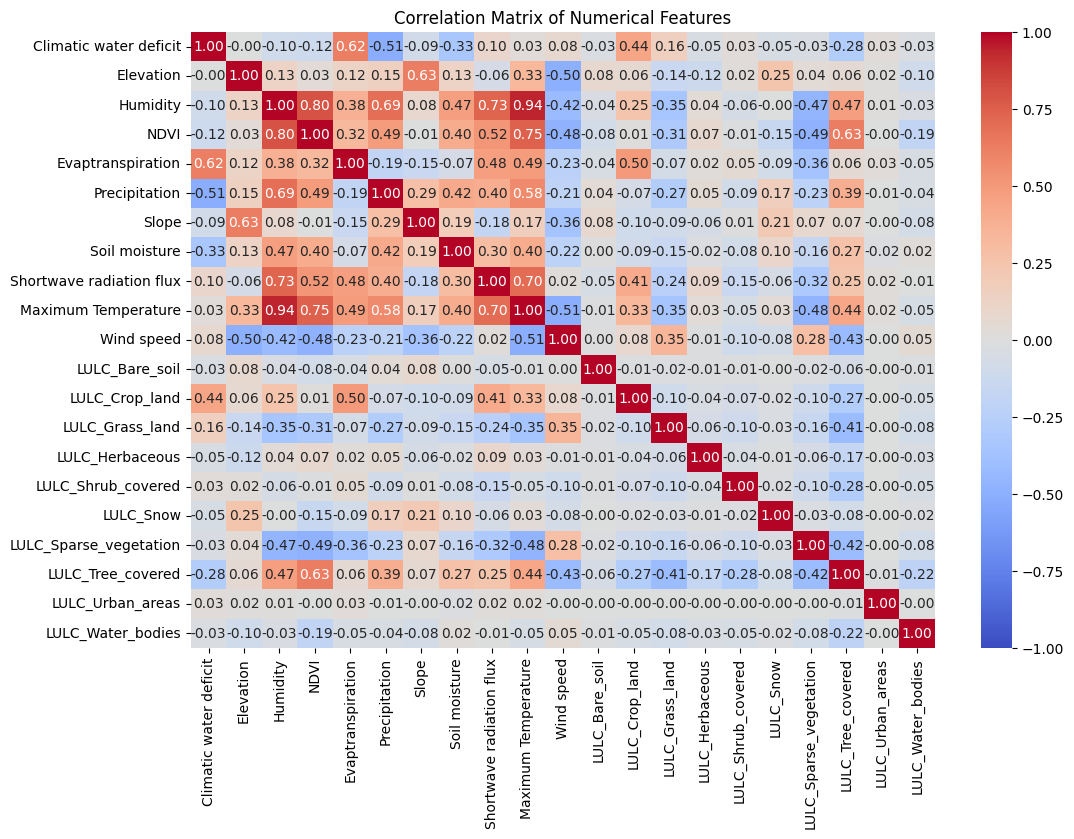

In [16]:
# Calculate correlation matrix for numerical features
correlation_matrix = X_train_final.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numerical Features")
plt.show()


In [17]:
print(df[['Maximum Temperature', 'Humidity', 'ndfb_kd_pr']].corr())

                     Maximum Temperature  Humidity  ndfb_kd_pr
Maximum Temperature             1.000000   0.93979    0.268498
Humidity                        0.939790   1.00000    0.200790
ndfb_kd_pr                      0.268498   0.20079    1.000000


In [18]:
# Initialize the RandomForestRegressor
rf = RandomForestRegressor(n_jobs=-1, max_depth=20, random_state=42)

# Fit the RandomForest model to get the feature importances
rf.fit(X_train_final, y_train)

# Initialize Boruta with the RandomForest model
boruta = BorutaPy(estimator=rf, n_estimators=20, max_iter=20, random_state=42, verbose=1)

# Fit Boruta on the preprocessed training data
boruta.fit(X_train_final.values, y_train.values)

# Create a DataFrame for the Boruta results
boruta_feature_stats = pd.DataFrame({
    'Variables': X_train_final.columns,
    'BorutaDecision': ['Confirmed' if decision else 'Rejected' for decision in boruta.support_]
})

# Initialize the DecisionTreeRegressor (CART)
cart_model = DecisionTreeRegressor(random_state=42)

# Fit the CART model to the training data
cart_model.fit(X_train_final, y_train)

# Extract feature importances
feature_importances = cart_model.feature_importances_

# Create a DataFrame for the CART results
cart_feature_stats = pd.DataFrame({
    'Variables': X_train_final.columns,
    'RelativeImportance': feature_importances
})

# Combine Boruta and CART results
combined_feature_stats = boruta_feature_stats.merge(cart_feature_stats, on='Variables')

# Save the combined feature stats (both confirmed and rejected) to a CSV file
combined_feature_stats.to_csv('final_feature_stats_with_rejected.csv', index=False)

# Features removed by Boruta
boruta_removed_features = combined_feature_stats[combined_feature_stats['BorutaDecision'] == 'Rejected']['Variables']

# Features with very low importance in CART (threshold < 0.0005)
cart_removed_features = combined_feature_stats[combined_feature_stats['RelativeImportance'] < 0.0005]['Variables']

# Combine the removed features from both methods
removed_features = pd.concat([boruta_removed_features, cart_removed_features]).unique()

# Print removed features
print("Features removed by Boruta or CART:", removed_features)

# Display the final feature stats for those that are kept
final_feature_stats = combined_feature_stats[~combined_feature_stats['Variables'].isin(removed_features)]
print(final_feature_stats)

# Save the final confirmed features to a CSV file for documentation
final_feature_stats.to_csv('final_confirmed_features.csv', index=False)

# Drop the removed features from the datasets automatically
X_train_selected = X_train_final.drop(columns=removed_features, errors='ignore')
X_val_selected = X_val_final.drop(columns=removed_features, errors='ignore')
X_test_selected = X_test_final.drop(columns=removed_features, errors='ignore')

# Save the selected features datasets for reference
X_train_selected.to_csv('X_train_selected.csv', index=False)
X_val_selected.to_csv('X_val_selected.csv', index=False)
X_test_selected.to_csv('X_test_selected.csv', index=False)

# Display summary
print(f"Final selected features saved to: 'X_train_selected.csv', 'X_val_selected.csv', and 'X_test_selected.csv'")
print("Full feature stats (with rejected) saved to 'final_feature_stats_with_rejected.csv'")


Iteration: 1 / 20
Iteration: 2 / 20
Iteration: 3 / 20
Iteration: 4 / 20
Iteration: 5 / 20
Iteration: 6 / 20
Iteration: 7 / 20
Iteration: 8 / 20
Iteration: 9 / 20
Iteration: 10 / 20
Iteration: 11 / 20
Iteration: 12 / 20
Iteration: 13 / 20
Iteration: 14 / 20
Iteration: 15 / 20
Iteration: 16 / 20
Iteration: 17 / 20
Iteration: 18 / 20
Iteration: 19 / 20


BorutaPy finished running.

Iteration: 	20 / 20
Confirmed: 	11
Tentative: 	0
Rejected: 	10
Features removed by Boruta or CART: ['Slope' 'LULC_Bare_soil' 'LULC_Grass_land' 'LULC_Herbaceous'
 'LULC_Shrub_covered' 'LULC_Snow' 'LULC_Sparse_vegetation'
 'LULC_Tree_covered' 'LULC_Urban_areas' 'LULC_Water_bodies'
 'LULC_Crop_land']
                   Variables BorutaDecision  RelativeImportance
0     Climatic water deficit      Confirmed            0.131686
1                  Elevation      Confirmed            0.092458
2                   Humidity      Confirmed            0.080377
3                       NDVI      Confirmed            0.011660

In [19]:
# # Load the CSV file
# file_path = "/content/final_feature_stats_with_rejected.csv"  # Update with your actual file path
# df1 = pd.read_csv(file_path)

# # Sort by 'RelativeImportance' in descending order
# df_sorted = df1.sort_values(by="RelativeImportance", ascending=False)  # Corrected 'ascending'

# # Save the sorted file
# df_sorted.to_csv("final_feature_stats_sorted.csv", index=False)

# # Display sorted DataFrame
# print(df_sorted)

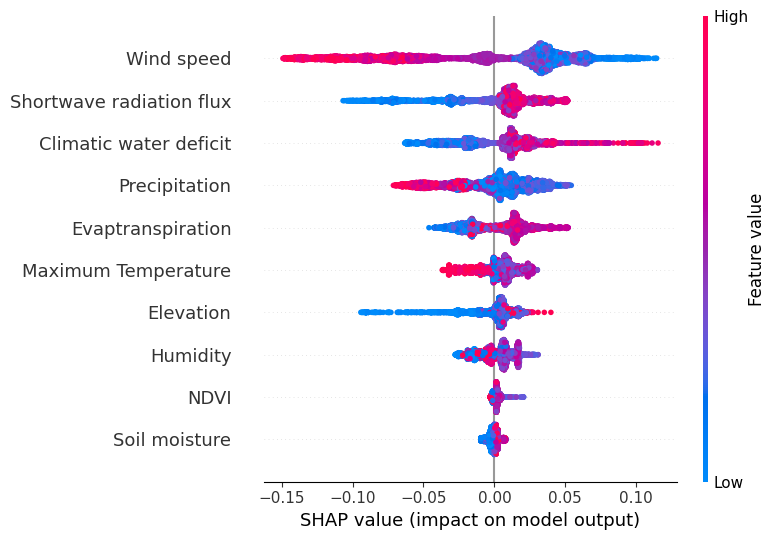

In [20]:
import shap
import xgboost as xgb
import matplotlib.pyplot as plt

# Convert datasets to XGBoost DMatrix for better performance (optional)
dtrain = xgb.DMatrix(X_train_selected, label=y_train)
dval = xgb.DMatrix(X_val_final, label=y_val)

# Train the XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.01, random_state=42)
xgb_model.fit(X_train_selected, y_train)

# Compute SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train_selected)

# SHAP summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_selected, feature_names=X_train_selected.columns)


In [21]:
X_train_selected

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed
0,-1.133414,1.035926,0.080131,-0.665452,-0.419763,0.338350,2.647702,-1.804288,0.409449,-0.375726
1,-1.400281,0.043614,1.725335,1.444613,-0.112759,1.767582,0.965830,1.209209,1.029985,-1.121174
2,0.850373,0.078572,-1.152890,-0.539342,0.322428,-0.935487,-1.077024,-0.920238,-1.211672,0.542841
3,0.397549,-0.741048,0.030034,0.472072,1.003368,-0.629116,-0.842372,-0.832746,-0.235247,-1.075899
4,-0.471050,1.677869,-0.140190,-0.296587,-0.236638,-0.131223,-0.264020,-0.696076,-0.029604,-1.787175
...,...,...,...,...,...,...,...,...,...,...
6763,-0.849923,-0.615212,-0.588495,-0.402178,-0.713214,-0.223227,0.190604,0.365659,-0.657176,0.914797
6764,0.084995,0.104626,-0.262312,-0.632926,0.764117,-0.611318,-0.992230,-1.494755,-0.363574,-1.121462
6765,-0.837191,-0.393527,0.275500,-0.449964,0.137551,0.769938,-0.763812,0.246924,0.172223,-0.121041
6766,0.328967,-1.109017,-1.030321,-1.021195,-1.211779,-0.625472,-0.425399,-0.142130,-0.823159,1.187019


In [22]:
X_test_selected

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed
0,1.369528,0.217263,1.489287,0.862050,-0.017022,1.865761,0.073428,1.127824,1.379889,-1.826433
1,-0.688856,-0.034242,1.629893,1.524625,0.319936,1.278656,2.332118,1.224059,1.162718,0.140859
2,0.188622,-1.071075,-1.540243,-1.442104,-0.537558,-0.863530,0.044134,-0.388342,-1.576642,1.610247
3,0.882878,0.150951,-0.886366,0.245580,0.872822,-0.852397,-1.248126,-1.943543,-0.848948,-0.648738
4,-0.783357,-0.768427,2.554804,1.623376,0.347040,1.886086,0.346215,1.400265,1.643689,-1.031360
...,...,...,...,...,...,...,...,...,...,...
1446,0.152607,-0.839132,0.741092,0.798344,0.093313,0.640331,0.114409,0.863869,0.560179,-0.991302
1447,1.288936,-0.496837,-1.037937,-0.429981,0.201042,-0.995475,-0.591060,-1.418835,-1.019242,-0.028977
1448,-0.860247,1.321835,-0.088691,0.571173,-0.697762,-0.111559,2.155818,-1.184772,0.433733,-1.688305
1449,-0.113409,0.943553,1.138817,0.813412,-1.301467,1.377918,2.485192,-0.416757,1.061595,-1.327562


In [23]:
X_val_selected

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed
0,-1.755514,-0.162939,-0.439693,-0.670267,-1.355580,0.949678,-0.491927,-0.451471,-0.001214,0.520245
1,-0.269411,-0.493210,1.672857,0.778668,0.375121,1.015110,2.682417,1.253630,1.213116,0.314591
2,0.081843,0.973808,1.095237,1.143090,-0.257537,-0.309145,1.382670,-0.345722,1.288797,-1.558461
3,-0.540218,-0.604776,0.523467,0.652064,-0.363697,0.496032,0.117446,0.756577,0.255658,-0.652373
4,-0.193547,0.013523,-0.528329,-0.778898,0.242265,-0.600723,1.025747,-0.186230,-0.649885,-0.145989
...,...,...,...,...,...,...,...,...,...,...
1445,0.003962,-0.068816,0.644719,1.243078,0.804242,-0.295343,0.748721,0.770334,0.560981,-0.451685
1446,-0.935952,-0.998468,-0.486416,-0.212082,-0.733773,0.411495,-0.817484,-0.568791,-0.142941,2.407357
1447,0.307274,1.460161,0.814665,2.214704,-0.197776,-0.311022,0.814201,-0.117959,1.217053,-1.416548
1448,-0.817700,-0.057446,1.301449,1.256207,0.162094,0.677872,1.090600,1.001053,1.045363,-0.724362


In [24]:
# Concatenate the index columns back with the selected features
X_train_final_with_indices = pd.concat([train_indices.reset_index(drop=True), X_train_selected.reset_index(drop=True)], axis=1)
X_val_final_with_indices = pd.concat([val_indices.reset_index(drop=True), X_val_selected.reset_index(drop=True)], axis=1)
X_test_final_with_indices = pd.concat([test_indices.reset_index(drop=True), X_test_selected.reset_index(drop=True)], axis=1)

# Save the updated datasets
X_train_final_with_indices.to_csv('X_train_final_with_indices.csv', index=False)
X_val_final_with_indices.to_csv('X_val_final_with_indices.csv', index=False)
X_test_final_with_indices.to_csv('X_test_final_with_indices.csv', index=False)


In [25]:
X_train_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed
0,114828,59.967217,-136.794667,0.000000,8.0,0.0,-1.061040,-1.133414,1.035926,0.080131,-0.665452,-0.419763,0.338350,2.647702,-1.804288,0.409449,-0.375726
1,6803,46.717217,-74.378000,0.000000,0.0,6.0,1.073450,-1.400281,0.043614,1.725335,1.444613,-0.112759,1.767582,0.965830,1.209209,1.029985,-1.121174
2,161704,65.467217,-114.461333,0.000000,0.0,18.0,0.037240,0.850373,0.078572,-1.152890,-0.539342,0.322428,-0.935487,-1.077024,-0.920238,-1.211672,0.542841
3,141911,63.383883,-123.544667,0.000000,4.0,18.0,-0.147227,0.397549,-0.741048,0.030034,0.472072,1.003368,-0.629116,-0.842372,-0.832746,-0.235247,-1.075899
4,123450,61.050550,-124.878000,0.000000,0.0,23.0,0.555500,-0.471050,1.677869,-0.140190,-0.296587,-0.236638,-0.131223,-0.264020,-0.696076,-0.029604,-1.787175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6763,101926,58.217217,-96.461333,0.000000,0.0,18.0,2.081110,-0.849923,-0.615212,-0.588495,-0.402178,-0.713214,-0.223227,0.190604,0.365659,-0.657176,0.914797
6764,159951,65.300550,-131.294667,0.000000,0.0,0.0,-0.659046,0.084995,0.104626,-0.262312,-0.632926,0.764117,-0.611318,-0.992230,-1.494755,-0.363574,-1.121462
6765,58758,53.383883,-74.044667,5.000000,0.0,0.0,0.733193,-0.837191,-0.393527,0.275500,-0.449964,0.137551,0.769938,-0.763812,0.246924,0.172223,-0.121041
6766,120524,60.633883,-77.128000,136.473007,0.0,0.0,-0.666750,0.328967,-1.109017,-1.030321,-1.021195,-1.211779,-0.625472,-0.425399,-0.142130,-0.823159,1.187019


In [26]:
X_val_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed
0,75658,55.050550,-61.711333,0.0,0.0,18.0,-0.768571,-1.755514,-0.162939,-0.439693,-0.670267,-1.355580,0.949678,-0.491927,-0.451471,-0.001214,0.520245
1,6724,46.717217,-80.961333,0.0,18.0,10.0,1.081500,-0.269411,-0.493210,1.672857,0.778668,0.375121,1.015110,2.682417,1.253630,1.213116,0.314591
2,67447,54.300550,-126.128000,0.0,0.0,16.0,-2.069910,0.081843,0.973808,1.095237,1.143090,-0.257537,-0.309145,1.382670,-0.345722,1.288797,-1.558461
3,49264,52.467217,-87.544667,0.0,0.0,0.0,2.176330,-0.540218,-0.604776,0.523467,0.652064,-0.363697,0.496032,0.117446,0.756577,0.255658,-0.652373
4,125588,61.300550,-108.044667,0.0,0.0,0.0,2.069520,-0.193547,0.013523,-0.528329,-0.778898,0.242265,-0.600723,1.025747,-0.186230,-0.649885,-0.145989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,88299,56.550550,-109.794667,0.0,0.0,29.0,0.286167,0.003962,-0.068816,0.644719,1.243078,0.804242,-0.295343,0.748721,0.770334,0.560981,-0.451685
1446,96199,57.467217,-62.544667,0.0,0.0,18.0,-0.822789,-0.935952,-0.998468,-0.486416,-0.212082,-0.733773,0.411495,-0.817484,-0.568791,-0.142941,2.407357
1447,55607,53.133883,-125.044667,0.0,0.0,23.0,-1.632170,0.307274,1.460161,0.814665,2.214704,-0.197776,-0.311022,0.814201,-0.117959,1.217053,-1.416548
1448,14215,48.717217,-90.544667,0.0,0.0,18.0,2.302580,-0.817700,-0.057446,1.301449,1.256207,0.162094,0.677872,1.090600,1.001053,1.045363,-0.724362


In [27]:
X_test_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed
0,36304,51.217217,-118.211333,0.000000,12.0,0.0,-0.670571,1.369528,0.217263,1.489287,0.862050,-0.017022,1.865761,0.073428,1.127824,1.379889,-1.826433
1,7410,46.967217,-82.294667,0.000000,0.0,22.0,1.913250,-0.688856,-0.034242,1.629893,1.524625,0.319936,1.278656,2.332118,1.224059,1.162718,0.140859
2,152188,64.467217,-87.961333,265.424011,0.0,0.0,-0.621333,0.188622,-1.071075,-1.540243,-1.442104,-0.537558,-0.863530,0.044134,-0.388342,-1.576642,1.610247
3,179783,67.383883,-138.211333,0.000000,0.0,0.0,-1.956910,0.882878,0.150951,-0.886366,0.245580,0.872822,-0.852397,-1.248126,-1.943543,-0.848948,-0.648738
4,4065,45.717217,-72.294667,0.000000,27.0,5.0,0.661176,-0.783357,-0.768427,2.554804,1.623376,0.347040,1.886086,0.346215,1.400265,1.643689,-1.031360
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1446,37536,51.300550,-84.794667,0.000000,0.0,18.0,1.352920,0.152607,-0.839132,0.741092,0.798344,0.093313,0.640331,0.114409,0.863869,0.560179,-0.991302
1447,183919,67.800550,-125.461333,0.000000,0.0,0.0,-1.116590,1.288936,-0.496837,-1.037937,-0.429981,0.201042,-0.995475,-0.591060,-1.418835,-1.019242,-0.028977
1448,116803,60.217217,-130.211333,0.000000,4.0,3.0,-0.223077,-0.860247,1.321835,-0.088691,0.571173,-0.697762,-0.111559,2.155818,-1.184772,0.433733,-1.688305
1449,61559,53.717217,-127.044667,0.000000,8.0,16.0,-1.537640,-0.113409,0.943553,1.138817,0.813412,-1.301467,1.377918,2.485192,-0.416757,1.061595,-1.327562


In [28]:
X_train_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed
0,114828,59.967217,-136.794667,0.000000,8.0,0.0,-1.061040,-1.133414,1.035926,0.080131,-0.665452,-0.419763,0.338350,2.647702,-1.804288,0.409449,-0.375726
1,6803,46.717217,-74.378000,0.000000,0.0,6.0,1.073450,-1.400281,0.043614,1.725335,1.444613,-0.112759,1.767582,0.965830,1.209209,1.029985,-1.121174
2,161704,65.467217,-114.461333,0.000000,0.0,18.0,0.037240,0.850373,0.078572,-1.152890,-0.539342,0.322428,-0.935487,-1.077024,-0.920238,-1.211672,0.542841
3,141911,63.383883,-123.544667,0.000000,4.0,18.0,-0.147227,0.397549,-0.741048,0.030034,0.472072,1.003368,-0.629116,-0.842372,-0.832746,-0.235247,-1.075899
4,123450,61.050550,-124.878000,0.000000,0.0,23.0,0.555500,-0.471050,1.677869,-0.140190,-0.296587,-0.236638,-0.131223,-0.264020,-0.696076,-0.029604,-1.787175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6763,101926,58.217217,-96.461333,0.000000,0.0,18.0,2.081110,-0.849923,-0.615212,-0.588495,-0.402178,-0.713214,-0.223227,0.190604,0.365659,-0.657176,0.914797
6764,159951,65.300550,-131.294667,0.000000,0.0,0.0,-0.659046,0.084995,0.104626,-0.262312,-0.632926,0.764117,-0.611318,-0.992230,-1.494755,-0.363574,-1.121462
6765,58758,53.383883,-74.044667,5.000000,0.0,0.0,0.733193,-0.837191,-0.393527,0.275500,-0.449964,0.137551,0.769938,-0.763812,0.246924,0.172223,-0.121041
6766,120524,60.633883,-77.128000,136.473007,0.0,0.0,-0.666750,0.328967,-1.109017,-1.030321,-1.021195,-1.211779,-0.625472,-0.425399,-0.142130,-0.823159,1.187019


In [29]:
# Define the features to drop
features_to_drop = ['dist_fores', 'human_foot', 'pdsi', 'tree_speci']

# Load the datasets
train_file = "X_train_final_with_indices.csv"
val_file = "X_val_final_with_indices.csv"
test_file = "X_test_final_with_indices.csv"

X_train_final_with_indices = pd.read_csv(train_file)
X_val_final_with_indices = pd.read_csv(val_file)
X_test_final_with_indices = pd.read_csv(test_file)

# Drop the specified features
X_train_final_with_indices.drop(columns=features_to_drop, errors='ignore', inplace=True)
X_val_final_with_indices.drop(columns=features_to_drop, errors='ignore', inplace=True)
X_test_final_with_indices.drop(columns=features_to_drop, errors='ignore', inplace=True)

# Save the updated datasets
train_updated_file = "X_train_final_with_indices_updated.csv"
val_updated_file = "X_val_final_with_indices_updated.csv"
test_updated_file = "X_test_final_with_indices_updated.csv"

X_train_final_with_indices.to_csv(train_updated_file, index=False)
X_val_final_with_indices.to_csv(val_updated_file, index=False)
X_test_final_with_indices.to_csv(test_updated_file, index=False)



In [30]:
X_train_final_with_indices

,point_id,lat_dd,long_dd,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed
0,114828,59.967217,-136.794667,-1.133414,1.035926,0.080131,-0.665452,-0.419763,0.338350,2.647702,-1.804288,0.409449,-0.375726
1,6803,46.717217,-74.378000,-1.400281,0.043614,1.725335,1.444613,-0.112759,1.767582,0.965830,1.209209,1.029985,-1.121174
2,161704,65.467217,-114.461333,0.850373,0.078572,-1.152890,-0.539342,0.322428,-0.935487,-1.077024,-0.920238,-1.211672,0.542841
3,141911,63.383883,-123.544667,0.397549,-0.741048,0.030034,0.472072,1.003368,-0.629116,-0.842372,-0.832746,-0.235247,-1.075899
4,123450,61.050550,-124.878000,-0.471050,1.677869,-0.140190,-0.296587,-0.236638,-0.131223,-0.264020,-0.696076,-0.029604,-1.787175
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6763,101926,58.217217,-96.461333,-0.849923,-0.615212,-0.588495,-0.402178,-0.713214,-0.223227,0.190604,0.365659,-0.657176,0.914797
6764,159951,65.300550,-131.294667,0.084995,0.104626,-0.262312,-0.632926,0.764117,-0.611318,-0.992230,-1.494755,-0.363574,-1.121462
6765,58758,53.383883,-74.044667,-0.837191,-0.393527,0.275500,-0.449964,0.137551,0.769938,-0.763812,0.246924,0.172223,-0.121041
6766,120524,60.633883,-77.128000,0.328967,-1.109017,-1.030321,-1.021195,-1.211779,-0.625472,-0.425399,-0.142130,-0.823159,1.187019


In [31]:
X_val_final_with_indices

,point_id,lat_dd,long_dd,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed
0,75658,55.050550,-61.711333,-1.755514,-0.162939,-0.439693,-0.670267,-1.355580,0.949678,-0.491927,-0.451471,-0.001214,0.520245
1,6724,46.717217,-80.961333,-0.269411,-0.493210,1.672857,0.778668,0.375121,1.015110,2.682417,1.253630,1.213116,0.314591
2,67447,54.300550,-126.128000,0.081843,0.973808,1.095237,1.143090,-0.257537,-0.309145,1.382670,-0.345722,1.288797,-1.558461
3,49264,52.467217,-87.544667,-0.540218,-0.604776,0.523467,0.652064,-0.363697,0.496032,0.117446,0.756577,0.255658,-0.652373
4,125588,61.300550,-108.044667,-0.193547,0.013523,-0.528329,-0.778898,0.242265,-0.600723,1.025747,-0.186230,-0.649885,-0.145989
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,88299,56.550550,-109.794667,0.003962,-0.068816,0.644719,1.243078,0.804242,-0.295343,0.748721,0.770334,0.560981,-0.451685
1446,96199,57.467217,-62.544667,-0.935952,-0.998468,-0.486416,-0.212082,-0.733773,0.411495,-0.817484,-0.568791,-0.142941,2.407357
1447,55607,53.133883,-125.044667,0.307274,1.460161,0.814665,2.214704,-0.197776,-0.311022,0.814201,-0.117959,1.217053,-1.416548
1448,14215,48.717217,-90.544667,-0.817700,-0.057446,1.301449,1.256207,0.162094,0.677872,1.090600,1.001053,1.045363,-0.724362


In [32]:
X_test_final_with_indices

,point_id,lat_dd,long_dd,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed
0,36304,51.217217,-118.211333,1.369528,0.217263,1.489287,0.862050,-0.017022,1.865761,0.073428,1.127824,1.379889,-1.826433
1,7410,46.967217,-82.294667,-0.688856,-0.034242,1.629893,1.524625,0.319936,1.278656,2.332118,1.224059,1.162718,0.140859
2,152188,64.467217,-87.961333,0.188622,-1.071075,-1.540243,-1.442104,-0.537558,-0.863530,0.044134,-0.388342,-1.576642,1.610247
3,179783,67.383883,-138.211333,0.882878,0.150951,-0.886366,0.245580,0.872822,-0.852397,-1.248126,-1.943543,-0.848948,-0.648738
4,4065,45.717217,-72.294667,-0.783357,-0.768427,2.554804,1.623376,0.347040,1.886086,0.346215,1.400265,1.643689,-1.031360
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1446,37536,51.300550,-84.794667,0.152607,-0.839132,0.741092,0.798344,0.093313,0.640331,0.114409,0.863869,0.560179,-0.991302
1447,183919,67.800550,-125.461333,1.288936,-0.496837,-1.037937,-0.429981,0.201042,-0.995475,-0.591060,-1.418835,-1.019242,-0.028977
1448,116803,60.217217,-130.211333,-0.860247,1.321835,-0.088691,0.571173,-0.697762,-0.111559,2.155818,-1.184772,0.433733,-1.688305
1449,61559,53.717217,-127.044667,-0.113409,0.943553,1.138817,0.813412,-1.301467,1.377918,2.485192,-0.416757,1.061595,-1.327562


## K-fold spatial cross validation

In [33]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Load dataset
train_file_path = "X_train_final_with_indices.csv"  # Update with your file path
X_train_final_with_indices = pd.read_csv(train_file_path)

# Extract latitude and longitude
coordinates = X_train_final_with_indices[['lat_dd', 'long_dd']]

# Apply K-Means clustering to assign 10 spatial regions
n_splits = 10
kmeans = KMeans(n_clusters=n_splits, random_state=42, n_init=10)
X_train_final_with_indices['spatial_fold'] = kmeans.fit_predict(coordinates)

# Save the corrected spatial folds dataset
X_train_final_with_indices.to_csv("X_train_final_with_corrected_spatial_folds.csv", index=False)

# Display unique fold values
print("Unique spatial folds assigned:", X_train_final_with_indices['spatial_fold'].unique())
print("Spatial folds have been reassigned and saved to 'X_train_final_with_corrected_spatial_folds.csv'.")


Unique spatial folds assigned: [3 4 9 0 5 1 8 6 7 2]
Spatial folds have been reassigned and saved to 'X_train_final_with_corrected_spatial_folds.csv'.


In [34]:
tmp = pd.read_csv('X_train_final_with_corrected_spatial_folds.csv')
tmp

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,spatial_fold
0,114828,59.967217,-136.794667,0.000000,8.0,0.0,-1.061040,-1.133414,1.035926,0.080131,-0.665452,-0.419763,0.338350,2.647702,-1.804288,0.409449,-0.375726,3
1,6803,46.717217,-74.378000,0.000000,0.0,6.0,1.073450,-1.400281,0.043614,1.725335,1.444613,-0.112759,1.767582,0.965830,1.209209,1.029985,-1.121174,4
2,161704,65.467217,-114.461333,0.000000,0.0,18.0,0.037240,0.850373,0.078572,-1.152890,-0.539342,0.322428,-0.935487,-1.077024,-0.920238,-1.211672,0.542841,9
3,141911,63.383883,-123.544667,0.000000,4.0,18.0,-0.147227,0.397549,-0.741048,0.030034,0.472072,1.003368,-0.629116,-0.842372,-0.832746,-0.235247,-1.075899,9
4,123450,61.050550,-124.878000,0.000000,0.0,23.0,0.555500,-0.471050,1.677869,-0.140190,-0.296587,-0.236638,-0.131223,-0.264020,-0.696076,-0.029604,-1.787175,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6763,101926,58.217217,-96.461333,0.000000,0.0,18.0,2.081110,-0.849923,-0.615212,-0.588495,-0.402178,-0.713214,-0.223227,0.190604,0.365659,-0.657176,0.914797,2
6764,159951,65.300550,-131.294667,0.000000,0.0,0.0,-0.659046,0.084995,0.104626,-0.262312,-0.632926,0.764117,-0.611318,-0.992230,-1.494755,-0.363574,-1.121462,3
6765,58758,53.383883,-74.044667,5.000000,0.0,0.0,0.733193,-0.837191,-0.393527,0.275500,-0.449964,0.137551,0.769938,-0.763812,0.246924,0.172223,-0.121041,4
6766,120524,60.633883,-77.128000,136.473007,0.0,0.0,-0.666750,0.328967,-1.109017,-1.030321,-1.021195,-1.211779,-0.625472,-0.425399,-0.142130,-0.823159,1.187019,4


In [35]:
tmp['spatial_fold'].value_counts(normalize=True)

,proportion
spatial_fold,
3,0.119090
4,0.118942
2,0.110077
0,0.108599
8,0.108008
5,0.106974
9,0.096188
6,0.082742
1,0.082004


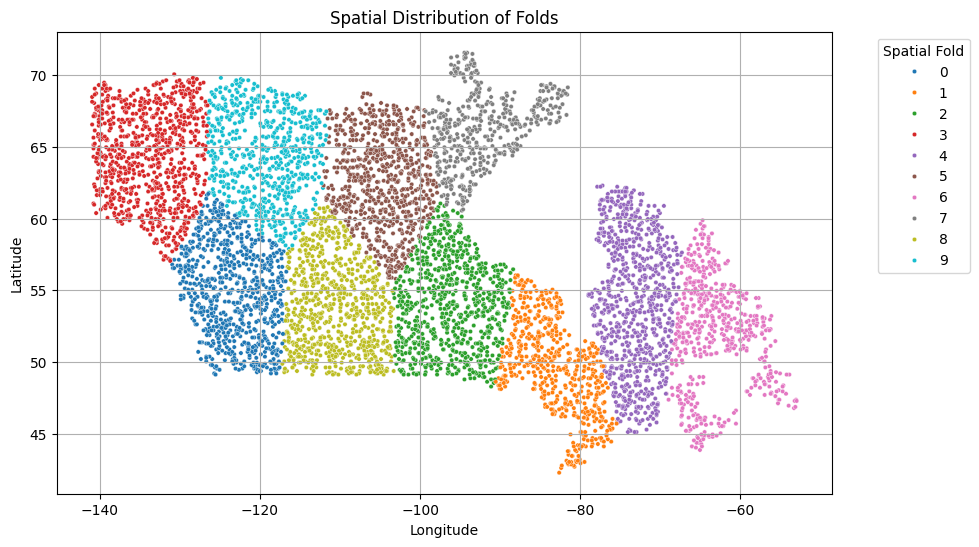

In [36]:
# Scatter plot of spatial folds
plt.figure(figsize=(10, 6))
sns.scatterplot(x=tmp["long_dd"], y=tmp["lat_dd"], hue=tmp["spatial_fold"], palette="tab10", s=10)
plt.title("Spatial Distribution of Folds")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Spatial Fold", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

In [37]:
X_train_final_with_indices.columns

Index(['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot',
       'tree_speci', 'pdsi', 'Climatic water deficit', 'Elevation', 'Humidity',
       'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
       'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',
       'spatial_fold'],
      dtype='object')

In [38]:
X_test_final_with_indices.columns

Index(['point_id', 'lat_dd', 'long_dd', 'Climatic water deficit', 'Elevation',
       'Humidity', 'NDVI', 'Evaptranspiration', 'Precipitation',
       'Soil moisture', 'Shortwave radiation flux', 'Maximum Temperature',
       'Wind speed'],
      dtype='object')

In [39]:
X_val_final_with_indices.columns

Index(['point_id', 'lat_dd', 'long_dd', 'Climatic water deficit', 'Elevation',
       'Humidity', 'NDVI', 'Evaptranspiration', 'Precipitation',
       'Soil moisture', 'Shortwave radiation flux', 'Maximum Temperature',
       'Wind speed'],
      dtype='object')

In [40]:
# Define features to drop
drop_features = ["point_id", "lat_dd", "long_dd", "dist_fores", "human_foot", "tree_speci", "pdsi"]

# Load the datasets
train_file = "X_train_final_with_corrected_spatial_folds.csv"
val_file = "X_val_final_with_indices.csv"
test_file = "X_test_final_with_indices.csv"

X_train_final_with_indices = pd.read_csv(train_file)
X_val_final_with_indices = pd.read_csv(val_file)
X_test_final_with_indices = pd.read_csv(test_file)

# Drop the specified features from training, validation, and test datasets
X_train_final_with_indices.drop(columns=drop_features, errors='ignore', inplace=True)
X_val_final_with_indices.drop(columns=drop_features, errors='ignore', inplace=True)
X_test_final_with_indices.drop(columns=drop_features, errors='ignore', inplace=True)

# Save the cleaned datasets
X_train_final_with_indices.to_csv("X_train_final_cleaned.csv", index=False)
X_val_final_with_indices.to_csv("X_val_final_cleaned.csv", index=False)
X_test_final_with_indices.to_csv("X_test_final_cleaned.csv", index=False)



In [41]:
X_train_final_with_indices

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,spatial_fold
0,-1.133414,1.035926,0.080131,-0.665452,-0.419763,0.338350,2.647702,-1.804288,0.409449,-0.375726,3
1,-1.400281,0.043614,1.725335,1.444613,-0.112759,1.767582,0.965830,1.209209,1.029985,-1.121174,4
2,0.850373,0.078572,-1.152890,-0.539342,0.322428,-0.935487,-1.077024,-0.920238,-1.211672,0.542841,9
3,0.397549,-0.741048,0.030034,0.472072,1.003368,-0.629116,-0.842372,-0.832746,-0.235247,-1.075899,9
4,-0.471050,1.677869,-0.140190,-0.296587,-0.236638,-0.131223,-0.264020,-0.696076,-0.029604,-1.787175,0
...,...,...,...,...,...,...,...,...,...,...,...
6763,-0.849923,-0.615212,-0.588495,-0.402178,-0.713214,-0.223227,0.190604,0.365659,-0.657176,0.914797,2
6764,0.084995,0.104626,-0.262312,-0.632926,0.764117,-0.611318,-0.992230,-1.494755,-0.363574,-1.121462,3
6765,-0.837191,-0.393527,0.275500,-0.449964,0.137551,0.769938,-0.763812,0.246924,0.172223,-0.121041,4
6766,0.328967,-1.109017,-1.030321,-1.021195,-1.211779,-0.625472,-0.425399,-0.142130,-0.823159,1.187019,4


In [42]:
X_val_final_with_indices

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed
0,-1.755514,-0.162939,-0.439693,-0.670267,-1.355580,0.949678,-0.491927,-0.451471,-0.001214,0.520245
1,-0.269411,-0.493210,1.672857,0.778668,0.375121,1.015110,2.682417,1.253630,1.213116,0.314591
2,0.081843,0.973808,1.095237,1.143090,-0.257537,-0.309145,1.382670,-0.345722,1.288797,-1.558461
3,-0.540218,-0.604776,0.523467,0.652064,-0.363697,0.496032,0.117446,0.756577,0.255658,-0.652373
4,-0.193547,0.013523,-0.528329,-0.778898,0.242265,-0.600723,1.025747,-0.186230,-0.649885,-0.145989
...,...,...,...,...,...,...,...,...,...,...
1445,0.003962,-0.068816,0.644719,1.243078,0.804242,-0.295343,0.748721,0.770334,0.560981,-0.451685
1446,-0.935952,-0.998468,-0.486416,-0.212082,-0.733773,0.411495,-0.817484,-0.568791,-0.142941,2.407357
1447,0.307274,1.460161,0.814665,2.214704,-0.197776,-0.311022,0.814201,-0.117959,1.217053,-1.416548
1448,-0.817700,-0.057446,1.301449,1.256207,0.162094,0.677872,1.090600,1.001053,1.045363,-0.724362


In [43]:
X_test_final_with_indices

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed
0,1.369528,0.217263,1.489287,0.862050,-0.017022,1.865761,0.073428,1.127824,1.379889,-1.826433
1,-0.688856,-0.034242,1.629893,1.524625,0.319936,1.278656,2.332118,1.224059,1.162718,0.140859
2,0.188622,-1.071075,-1.540243,-1.442104,-0.537558,-0.863530,0.044134,-0.388342,-1.576642,1.610247
3,0.882878,0.150951,-0.886366,0.245580,0.872822,-0.852397,-1.248126,-1.943543,-0.848948,-0.648738
4,-0.783357,-0.768427,2.554804,1.623376,0.347040,1.886086,0.346215,1.400265,1.643689,-1.031360
...,...,...,...,...,...,...,...,...,...,...
1446,0.152607,-0.839132,0.741092,0.798344,0.093313,0.640331,0.114409,0.863869,0.560179,-0.991302
1447,1.288936,-0.496837,-1.037937,-0.429981,0.201042,-0.995475,-0.591060,-1.418835,-1.019242,-0.028977
1448,-0.860247,1.321835,-0.088691,0.571173,-0.697762,-0.111559,2.155818,-1.184772,0.433733,-1.688305
1449,-0.113409,0.943553,1.138817,0.813412,-1.301467,1.377918,2.485192,-0.416757,1.061595,-1.327562


In [44]:
X_train_final_with_indices.shape

(6768, 11)

In [45]:
y_train.shape

(6768,)

## 10-fold spatial cross-validation splitting

In [46]:
# Ensure indices are aligned
X_train_final_with_indices = X_train_final_with_indices.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# Extract unique spatial folds
unique_folds = sorted(X_train_final_with_indices["spatial_fold"].unique())

# Prepare to store spatial fold splits
spatial_cv_splits = []

# Perform 10-Fold Spatial Cross-Validation Splitting
for fold in unique_folds:
    print(f"🔹 Preparing Fold {fold}...")

    # Define train and validation sets based on spatial fold
    train_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] != fold]
    val_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] == fold]

    # Extract train and validation indices
    train_indices = train_data.index
    val_indices = val_data.index

    # Drop "spatial_fold" from feature sets
    X_train_fold = train_data.drop(columns=["spatial_fold"])
    X_val_fold = val_data.drop(columns=["spatial_fold"])

    # Extract corresponding target values
    y_train_fold = y_train.iloc[train_indices]
    y_val_fold = y_train.iloc[val_indices]

    # Store the train-validation split for this fold
    spatial_cv_splits.append({
        "fold": fold,
        "X_train": X_train_fold,
        "y_train": y_train_fold,
        "X_val": X_val_fold,
        "y_val": y_val_fold
    })

print(f"\n✅ 10-Fold Spatial Cross-Validation Splits Prepared ({len(spatial_cv_splits)} Folds)")


🔹 Preparing Fold 0...
🔹 Preparing Fold 1...
🔹 Preparing Fold 2...
🔹 Preparing Fold 3...
🔹 Preparing Fold 4...
🔹 Preparing Fold 5...
🔹 Preparing Fold 6...
🔹 Preparing Fold 7...
🔹 Preparing Fold 8...
🔹 Preparing Fold 9...

✅ 10-Fold Spatial Cross-Validation Splits Prepared (10 Folds)


In [47]:
X_train.shape

(6768, 13)

In [48]:
y_train.shape

(6768,)

In [49]:
X_train_fold.shape

(6117, 10)

In [50]:
y_train_fold.shape

(6117,)

In [51]:
 X_val_fold.shape

(651, 10)

### Approach

1. Spatial K-fold cross-validation is for model selection, NOT Final training

* In spatial K-fold CV, we train on 9 folds and validate on 1 fold.
* each model in spatial CV is trained on only 90% of the trainig data, which means it does not fully utilize all available training data.
2. Final Model should be trained on FULL training data.
* Once we determine the best model, we should train it on 100% of the training data
* This ensures the model learns all available patterns.

# Deep Neural Network

### Train DNN model using 10-fold CV

This code ensures that each fold is used for validation once, while the remaining 9 folds are used for training.

1. 10-Fold Spatial Cross-Validation

* Train on 9 folds, validate on 1 fold.
* Repeat for each fold.
* Store validation metrics.
2. Train the Final Model

* Use full training dataset (X_train_final_with_indices).
* Validate using separate validation data (X_val_final_with_indices).
3. Evaluate on the Test Set

* Measure performance on unseen test data (X_test_final_with_indices).


🔹 Training Fold 0 (Train on 9 folds, Validate on 1 fold)...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0318 - mae: 0.1235 - val_loss: 0.0355 - val_mae: 0.1437
Epoch 2/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0070 - mae: 0.0603 - val_loss: 0.0266 - val_mae: 0.1262
Epoch 3/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0052 - mae: 0.0523 - val_loss: 0.0225 - val_mae: 0.1122
Epoch 4/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0041 - mae: 0.0471 - val_loss: 0.0254 - val_mae: 0.1224
Epoch 5/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0036 - mae: 0.0437 - val_loss: 0.0215 - val_mae: 0.1077
Epoch 6/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0031 - mae: 0.0399 - val_loss: 0.0160 - val_mae: 0.0918
Epoch 7/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0028 - mae: 0.0387 - val_loss: 0.0184 - val_mae: 0.1003
Epoch 8/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0025 - mae: 0.0364 - val_loss: 0.0220 - val_mae: 0.1104
Epoch 9/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0419 - mae: 0.1363 - val_loss: 0.0249 - val_mae: 0.1271
Epoch 2/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0098 - mae: 0.0717 - val_loss: 0.0277 - val_mae: 0.1331
Epoch 3/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0064 - mae: 0.0589 - val_loss: 0.0303 - val_mae: 0.1339
Epoch 4/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0051 - mae: 0.0516 - val_loss: 0.0345 - val_mae: 0.1506
Epoch 5/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0043 - mae: 0.0485 - val_loss: 0.0184 - val_mae: 0.1002
Epoch 6/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0040 - mae: 0.0461 - val_loss: 0.0293 - val_mae: 0.1340
Epoch 7/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0036 - mae: 0.0437 - val_loss: 0.0273 - val_mae: 0.1267
Epoch 8/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0034 - mae: 0.0425 - val_loss: 0.0165 - val_mae: 0.0945
Epoch 9/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss:

...

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0367 - mae: 0.1334 - val_loss: 0.0133 - val_mae: 0.0856
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0096 - mae: 0.0698 - val_loss: 0.0088 - val_mae: 0.0673
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0060 - mae: 0.0573 - val_loss: 0.0109 - val_mae: 0.0751
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0051 - mae: 0.0524 - val_loss: 0.0075 - val_mae: 0.0632
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0042 - mae: 0.0475 - val_loss: 0.0087 - val_mae: 0.0702
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0039 - mae: 0.0451 - val_loss: 0.0071 - val_mae: 0.0654
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0034 - mae: 0.0418 - val_loss: 0.0085 - val_mae: 0.0688
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0032 - mae: 0.0409 - val_loss: 0.0069 - val_mae: 0.0656
Epoch 9/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss:

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0322 - mae: 0.1274 - val_loss: 0.0060 - val_mae: 0.0549
Epoch 2/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0082 - mae: 0.0647 - val_loss: 0.0038 - val_mae: 0.0429
Epoch 3/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0060 - mae: 0.0556 - val_loss: 0.0035 - val_mae: 0.0411
Epoch 4/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0048 - mae: 0.0497 - val_loss: 0.0028 - val_mae: 0.0377
Epoch 5/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0043 - mae: 0.0471 - val_loss: 0.0024 - val_mae: 0.0334
Epoch 6/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0034 - mae: 0.0426 - val_loss: 0.0023 - val_mae: 0.0340
Epoch 7/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0034 - mae: 0.0417 - val_loss: 0.0021 - val_mae: 0.0335
Epoch 8/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0031 - mae: 0.0397 - val_loss: 0.0022 - val_mae: 0.0347
Epoch 9/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss:


🎯 Final Model Performance on Test Data:
Test MSE: 0.0007
Test MAE: 0.0183
Test R² Score: 0.9846


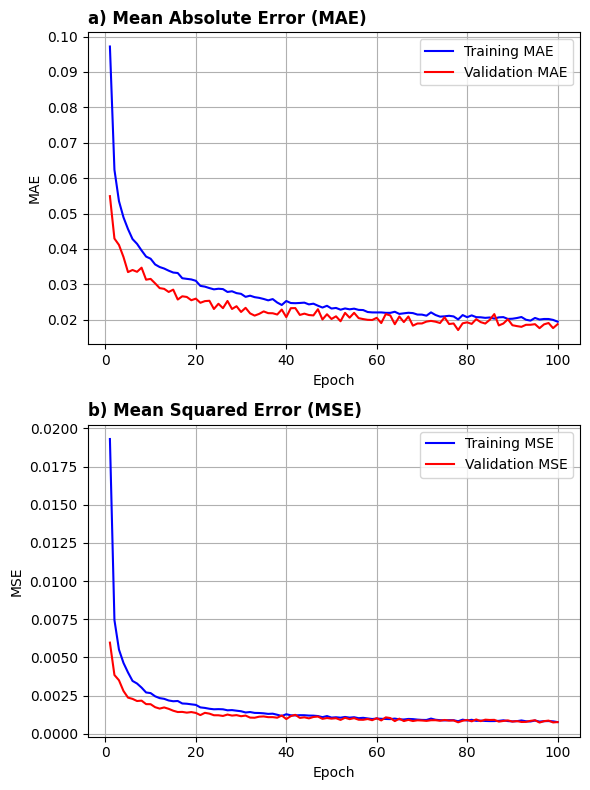

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define a function to create the DNN model
def create_dnn(input_shape, dropout_rate=0.1):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_shape,)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_dnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Store cross-validation results
cv_results = []

# Perform 10-Fold Spatial Cross-Validation
for fold_split in spatial_cv_splits:
    fold = fold_split["fold"]
    X_train_fold = fold_split["X_train"]
    y_train_fold = fold_split["y_train"]
    X_val_fold = fold_split["X_val"]
    y_val_fold = fold_split["y_val"]

    print(f"\n🔹 Training Fold {fold} (Train on 9 folds, Validate on 1 fold)...")

    # Define input shape
    input_shape = X_train_fold.shape[1]

    # Create and compile the model
    dnn_model = create_dnn(input_shape)
    dnn_model = compile_dnn(dnn_model)

    # Train the model
    history = dnn_model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        verbose=1
    )

    # Evaluate the model on the validation set
    val_loss, val_mae = dnn_model.evaluate(X_val_fold, y_val_fold, verbose=0)

    # Make predictions on the validation set
    y_pred_val = dnn_model.predict(X_val_fold)

    # Calculate regression metrics
    mse = mean_squared_error(y_val_fold, y_pred_val)
    mae = mean_absolute_error(y_val_fold, y_pred_val)
    r2 = r2_score(y_val_fold, y_pred_val)

    # Store results
    cv_results.append({
        "Fold": fold,
        "Validation MSE": mse,
        "Validation MAE": mae,
        "Validation R²": r2
    })

    print(f"✅ Fold {fold} Results: MSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

# Convert results to DataFrame and display
cv_results_df = pd.DataFrame(cv_results)
print("\n📊 Cross-Validation Results:\n", cv_results_df)

# Train Final Model on Full Training Data
print("\n🚀 Training Final Model on Full Training Data...")
X_train_full = X_train_final_with_indices.drop(columns=["spatial_fold"])
y_train_full = y_train

input_shape = X_train_full.shape[1]
final_model = create_dnn(input_shape)
final_model = compile_dnn(final_model)

history_final = final_model.fit(
    X_train_full, y_train_full,
    validation_data=(X_val_final_with_indices, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Evaluate the final model on the test set
print("\n📊 Evaluating Final Model on Test Data...")
test_loss, test_mae = final_model.evaluate(X_test_final_with_indices, y_test, verbose=0)

# Make predictions on the test set
y_pred_test = final_model.predict(X_test_final_with_indices)

# Calculate final test metrics
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Display test metrics
print("\n🎯 Final Model Performance on Test Data:")
print(f"Test MSE: {mse_test:.4f}")
print(f"Test MAE: {mae_test:.4f}")
print(f"Test R² Score: {r2_test:.4f}")

# Save the final model
final_model.save('final_dnn_regression_model.h5')

# Plot training history
import matplotlib.pyplot as plt

def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)

    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']
    val_mse = history.history['val_loss']

    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE')
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

# Plot final model training history
plot_training_validation_metrics(history_final)


# TEST PREDICTION

In [53]:
# Load unseen data
df_unseen = pd.read_csv(
    'large_fires_data_v2_predictions.csv',
    names= [
        'point_id',
        'lat_dd',
        'long_dd',
        'Aspect',
        'Climatic water deficit',
        'Elevation',
        'Humidity',
        'LULC',
        'NDVI',
        'Evaptranspiration',
        'Precipitation',
        'Slope',
        'Soil moisture',
        'Shortwave radiation flux',
        'Maximum Temperature',
        'Wind speed',
        'dist_fores',
        'human_foot',
        'tree_speci',
        'pdsi'
    ],
    header= 0
)

In [54]:
# Replace -9999 with NaN
df_unseen.replace(-9999, np.nan, inplace=True)

# Verify if replacement was successful by checking for null values
df_unseen.isnull().sum()

,0
point_id,0
lat_dd,0
long_dd,0
Aspect,445
Climatic water deficit,1608
Elevation,3045
Humidity,2066
LULC,1838
NDVI,1979
Evaptranspiration,1604


In [55]:
# Fill missing values using forward fill, then backward fill
df_unseen.fillna(method='ffill', inplace=True)
df_unseen.fillna(method='bfill', inplace=True)

<ipython-input-55-d3e992b87ccb>:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_unseen.fillna(method='ffill', inplace=True)
<ipython-input-55-d3e992b87ccb>:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_unseen.fillna(method='bfill', inplace=True)


In [56]:
replace_values_LULC = {
    1: 'Urban_areas',
    2: 'Crop_land',
    3: 'Grass_land',
    4: 'Tree_covered',
    5: 'Shrub_covered',
    6: 'Herbaceous',
    8: 'Sparse_vegetation',
    9: 'Bare_soil',
    10: 'Snow',
    11: 'Water_bodies',
}

df_unseen['LULC'] = df_unseen['LULC'].replace(replace_values_LULC)
# Convert necessary columns to categorical
df_unseen = df_unseen.astype(
    {
        'LULC': 'category'
    }
)

In [57]:
# Define categorical, numerical, and additional columns
categorical_columns = ['LULC']
numerical_columns = [
    'Climatic water deficit', 'Elevation', 'Humidity', 'NDVI',
    'Evaptranspiration', 'Precipitation', 'Slope', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed'
]
additional_columns = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']  # Columns to retain


In [58]:
# Apply the trained encoder and scaler
X_unseen_encoded = pd.DataFrame(encoder.transform(df_unseen[categorical_columns]),
                                columns=encoder.get_feature_names_out(categorical_columns))
X_unseen_scaled = pd.DataFrame(scaler.transform(df_unseen[numerical_columns]), columns=numerical_columns)

# Concatenate encoded categorical and scaled numerical features
X_unseen_final = pd.concat([X_unseen_scaled.reset_index(drop=True), X_unseen_encoded.reset_index(drop=True)], axis=1)

# Save the processed unseen data to a CSV file
X_unseen_final.to_csv('unseen_data_preprocessed.csv', index=False)

# Display the first few rows of the processed data
X_unseen_final.head()

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Slope,Soil moisture,Shortwave radiation flux,Maximum Temperature,...,LULC_Bare_soil,LULC_Crop_land,LULC_Grass_land,LULC_Herbaceous,LULC_Shrub_covered,LULC_Snow,LULC_Sparse_vegetation,LULC_Tree_covered,LULC_Urban_areas,LULC_Water_bodies
0,0.235890,-0.650606,3.606709,2.956919,-1.416099,5.165150,-0.405558,10.047394,0.578700,1.808995,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.501232,-0.650606,3.606709,2.956919,-1.256096,4.229343,-0.405558,9.200096,0.655071,1.959905,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.480461,-0.650606,3.606709,2.956919,-1.265900,4.089548,-0.405558,8.782554,0.628971,1.879290,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.840256,-0.650606,3.606709,3.513260,-1.135172,3.026936,0.924616,7.599548,0.657577,1.923312,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.401187,-0.650606,3.590787,2.829750,-0.927897,1.739286,-0.405558,6.663895,0.703734,2.095714,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [59]:
# Extract additional columns from the original unseen dataframe
X_unseen_additional = df_unseen[additional_columns].reset_index(drop=True)

# Concatenate processed numerical, encoded categorical, and additional columns
X_unseen_final = pd.concat([X_unseen_additional, X_unseen_scaled.reset_index(drop=True), X_unseen_encoded.reset_index(drop=True)], axis=1)

# Save the final processed unseen data to a CSV file
X_unseen_final.to_csv('unseen_data_preprocessed.csv', index=False)

In [60]:
# Define features to be removed
features_to_remove = [
    'Slope', 'LULC_Bare_soil', 'LULC_Grass_land', 'LULC_Herbaceous',
    'LULC_Shrub_covered', 'LULC_Snow', 'LULC_Sparse_vegetation',
    'LULC_Tree_covered', 'LULC_Urban_areas', 'LULC_Water_bodies',
    'LULC_Crop_land']

# Drop the selected features from the unseen dataset
X_unseen_final_selected = X_unseen_final.drop(columns=features_to_remove, errors='ignore')

# Save the final feature-selected unseen dataset to a CSV file
X_unseen_final_selected.to_csv('unseen_data_preprocessed_selected.csv', index=False)

# Display the first few rows of the final dataset
X_unseen_final_selected.head()


,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed
0,12493,48.383883,-123.961333,0.0,18.0,0.0,-1.644420,0.235890,-0.650606,3.606709,2.956919,-1.416099,5.165150,10.047394,0.578700,1.808995,-0.218442
1,12494,48.383883,-123.878000,0.0,18.0,0.0,-1.360750,0.501232,-0.650606,3.606709,2.956919,-1.256096,4.229343,9.200096,0.655071,1.959905,-0.263540
2,12495,48.383883,-123.794667,0.0,18.0,0.0,-1.257080,0.480461,-0.650606,3.606709,2.956919,-1.265900,4.089548,8.782554,0.628971,1.879290,-0.378766
3,12497,48.383883,-123.628000,0.0,18.0,30.0,-0.977667,0.840256,-0.650606,3.606709,3.513260,-1.135172,3.026936,7.599548,0.657577,1.923312,-0.365126
4,12498,48.383883,-123.544667,0.0,41.0,0.0,-0.797250,1.401187,-0.650606,3.590787,2.829750,-0.927897,1.739286,6.663895,0.703734,2.095714,-0.362959


In [61]:
X_unseen_final_selected.columns

Index(['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot',
       'tree_speci', 'pdsi', 'Climatic water deficit', 'Elevation', 'Humidity',
       'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
       'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed'],
      dtype='object')

In [63]:
from tensorflow.keras.models import load_model
import tensorflow.keras.losses

# Define custom objects
custom_objects = {
    "mse": tensorflow.keras.losses.MeanSquaredError()
}

# Load the trained model with custom objects
final_model = load_model('final_dnn_regression_model.h5', custom_objects=custom_objects)


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'final_dnn_regression_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [62]:
# Load the preprocessed unseen data
X_unseen_final_selected = pd.read_csv('unseen_data_preprocessed.csv')

# Define the features used for prediction
features_for_prediction = [
    'Climatic water deficit', 'Elevation', 'Humidity',
    'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed'
]

# Select the necessary columns
X_unseen_for_prediction = X_unseen_final_selected[features_for_prediction]


In [ ]:
# Make predictions
predictions = final_model.predict(X_unseen_for_prediction)

# Rename the target column to wildfire_proba
X_unseen_final_selected['wildfire_proba'] = predictions

# Format wildfire_proba to 4 decimal places
X_unseen_final_selected['wildfire_proba'] = X_unseen_final_selected['wildfire_proba'].round(4)


5172/5172 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step


In [ ]:
# Define additional features to retain
additional_features = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']

# Select only the required columns
final_unseen_results = X_unseen_final_selected[additional_features + ['wildfire_proba']]

# Save the predictions to CSV
final_unseen_results.to_csv('prediction_dnn.csv', index=False)


In [ ]:
final_unseen_results

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,wildfire_proba
0,12493,48.383883,-123.961333,0.000000,18.0,0.0,-1.644420,0.0729
1,12494,48.383883,-123.878000,0.000000,18.0,0.0,-1.360750,0.0859
2,12495,48.383883,-123.794667,0.000000,18.0,0.0,-1.257080,0.1093
3,12497,48.383883,-123.628000,0.000000,18.0,30.0,-0.977667,0.1235
4,12498,48.383883,-123.544667,0.000000,41.0,0.0,-0.797250,0.1324
...,...,...,...,...,...,...,...,...
165493,209495,71.967217,-94.878000,551.724976,0.0,0.0,0.728250,0.0075
165494,209496,71.967217,-94.794667,551.724976,0.0,0.0,0.728250,0.0075
165495,209497,71.967217,-94.711333,555.090027,0.0,0.0,0.728250,0.0075
165496,209498,71.967217,-94.628000,555.090027,0.0,0.0,0.728250,0.0077


In [ ]:
df1 = pd.read_csv('prediction_dnn.csv')
df1

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,wildfire_proba
0,12493,48.383883,-123.961333,0.000000,18.0,0.0,-1.644420,0.0729
1,12494,48.383883,-123.878000,0.000000,18.0,0.0,-1.360750,0.0859
2,12495,48.383883,-123.794667,0.000000,18.0,0.0,-1.257080,0.1093
3,12497,48.383883,-123.628000,0.000000,18.0,30.0,-0.977667,0.1235
4,12498,48.383883,-123.544667,0.000000,41.0,0.0,-0.797250,0.1324
...,...,...,...,...,...,...,...,...
165493,209495,71.967217,-94.878000,551.724976,0.0,0.0,0.728250,0.0075
165494,209496,71.967217,-94.794667,551.724976,0.0,0.0,0.728250,0.0075
165495,209497,71.967217,-94.711333,555.090027,0.0,0.0,0.728250,0.0075
165496,209498,71.967217,-94.628000,555.090027,0.0,0.0,0.728250,0.0077


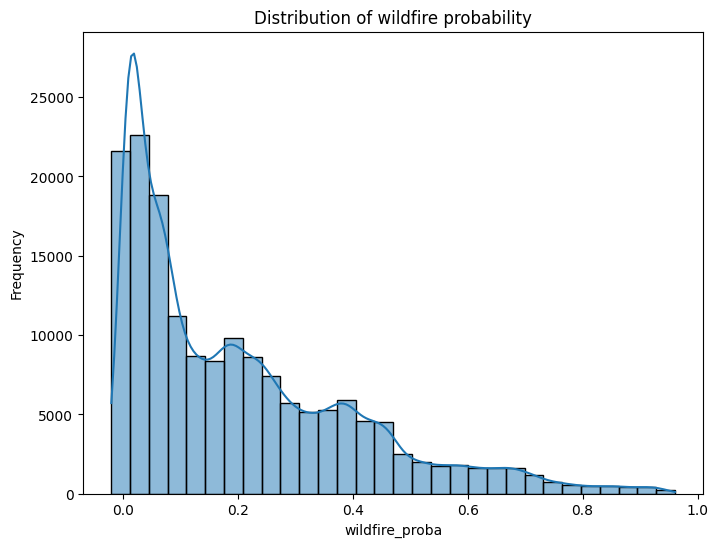

In [ ]:
# Plot the distribution of the target feature
plt.figure(figsize=(8, 6))
sns.histplot(df1['wildfire_proba'], bins=30, kde=True)
plt.xlabel('wildfire_proba')
plt.ylabel('Frequency')
plt.title('Distribution of wildfire probability')
plt.show()


# TEST BLOCK IS FINISHED

# BiRNN hyperparameter optimization (Grid Search with spatial 10-fold cv)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Bidirectional, SimpleRNN
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define a function to create the BiRNN model
def create_birnn(input_shape, dropout_rate=0.1):
    model = Sequential([
        Bidirectional(SimpleRNN(128, activation='relu', return_sequences=True), input_shape=(input_shape, 1)),
        Dropout(dropout_rate),
        Bidirectional(SimpleRNN(64, activation='relu')),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_birnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model


In [ ]:
# Store cross-validation results
cv_results = []

# Perform 10-Fold Spatial Cross-Validation
for fold_split in spatial_cv_splits:
    fold = fold_split["fold"]
    X_train_fold = fold_split["X_train"]
    y_train_fold = fold_split["y_train"]
    X_val_fold = fold_split["X_val"]
    y_val_fold = fold_split["y_val"]

    print(f"\n🔹 Training Fold {fold} (Train on 9 folds, Validate on 1 fold)...")

    # Reshape input data for BiRNN (RNNs expect 3D input: (samples, timesteps, features))
    X_train_fold = X_train_fold.values.reshape((X_train_fold.shape[0], X_train_fold.shape[1], 1))
    X_val_fold = X_val_fold.values.reshape((X_val_fold.shape[0], X_val_fold.shape[1], 1))

    # Define input shape
    input_shape = X_train_fold.shape[1]

    # Create and compile the BiRNN model
    birnn_model = create_birnn(input_shape)
    birnn_model = compile_birnn(birnn_model)

    # Train the model
    history = birnn_model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        verbose=1
    )

    # Evaluate the model on the validation set
    val_loss, val_mae = birnn_model.evaluate(X_val_fold, y_val_fold, verbose=0)

    # Make predictions on the validation set
    y_pred_val = birnn_model.predict(X_val_fold)

    # Calculate regression metrics
    mse = mean_squared_error(y_val_fold, y_pred_val)
    mae = mean_absolute_error(y_val_fold, y_pred_val)
    r2 = r2_score(y_val_fold, y_pred_val)

    # Store results
    cv_results.append({
        "Fold": fold,
        "Validation MSE": mse,
        "Validation MAE": mae,
        "Validation R²": r2
    })

    print(f"✅ Fold {fold} Results: MSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

# Convert results to DataFrame and display
cv_results_df = pd.DataFrame(cv_results)
print("\n📊 Cross-Validation Results:\n", cv_results_df)



🔹 Training Fold 0 (Train on 9 folds, Validate on 1 fold)...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0237 - mae: 0.1038 - val_loss: 0.0603 - val_mae: 0.1922
Epoch 2/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0049 - mae: 0.0504 - val_loss: 0.0346 - val_mae: 0.1450
Epoch 3/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0036 - mae: 0.0435 - val_loss: 0.0336 - val_mae: 0.1395
Epoch 4/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 0.0029 - mae: 0.0384 - val_loss: 0.0350 - val_mae: 0.1450
Epoch 5/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 0.0025 - mae: 0.0367 - val_loss: 0.0297 - val_mae: 0.1301
Epoch 6/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 0.0022 - mae: 0.0334 - val_loss: 0.0325 - val_mae: 0.1347
Epoch 7/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - loss: 0.0020 - mae: 0.0322 - val_loss: 0.0352 - val_mae: 0.1420
Epoch 8/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.0020 - mae: 0.0316 - val_loss: 0.0305 - val_mae: 0.1288
Epoch 9/100
189/189 ━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


195/195 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.0282 - mae: 0.1149 - val_loss: 0.0353 - val_mae: 0.1372
Epoch 2/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0060 - mae: 0.0564 - val_loss: 0.0172 - val_mae: 0.0942
Epoch 3/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0047 - mae: 0.0492 - val_loss: 0.0388 - val_mae: 0.1430
Epoch 4/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0034 - mae: 0.0420 - val_loss: 0.0281 - val_mae: 0.1240
Epoch 5/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0030 - mae: 0.0399 - val_loss: 0.0254 - val_mae: 0.1221
Epoch 6/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0026 - mae: 0.0370 - val_loss: 0.0252 - val_mae: 0.1174
Epoch 7/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0027 - mae: 0.0372 - val_loss: 0.0207 - val_mae: 0.1083
Epoch 8/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0022 - mae: 0.0336 - val_loss: 0.0184 - val_mae: 0.0974
Epoch 9/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/st

...

198/198 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0295 - mae: 0.1177 - val_loss: 6.5985e-04 - val_mae: 0.0178
Epoch 2/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0058 - mae: 0.0557 - val_loss: 5.2781e-04 - val_mae: 0.0202
Epoch 3/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0044 - mae: 0.0488 - val_loss: 5.2625e-04 - val_mae: 0.0153
Epoch 4/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0036 - mae: 0.0434 - val_loss: 6.5530e-04 - val_mae: 0.0209
Epoch 5/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0031 - mae: 0.0407 - val_loss: 4.1786e-04 - val_mae: 0.0168
Epoch 6/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0027 - mae: 0.0383 - val_loss: 3.1083e-04 - val_mae: 0.0133
Epoch 7/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0023 - mae: 0.0353 - val_loss: 3.9433e-04 - val_mae: 0.0149
Epoch 8/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0022 - mae: 0.0342 - val_loss: 4.1832e-04 - val_mae: 0.0151
Epoch 9/100
198/198

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0252 - mae: 0.1096 - val_loss: 0.0213 - val_mae: 0.1219
Epoch 2/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0053 - mae: 0.0534 - val_loss: 0.0144 - val_mae: 0.0984
Epoch 3/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0036 - mae: 0.0442 - val_loss: 0.0189 - val_mae: 0.1027
Epoch 4/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0031 - mae: 0.0405 - val_loss: 0.0104 - val_mae: 0.0794
Epoch 5/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0026 - mae: 0.0366 - val_loss: 0.0138 - val_mae: 0.0875
Epoch 6/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0023 - mae: 0.0347 - val_loss: 0.0136 - val_mae: 0.0857
Epoch 7/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0021 - mae: 0.0327 - val_loss: 0.0089 - val_mae: 0.0714
Epoch 8/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0018 - mae: 0.0305 - val_loss: 0.0095 - val_mae: 0.0743
Epoch 9/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/st

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


192/192 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - loss: 0.0303 - mae: 0.1185 - val_loss: 0.0163 - val_mae: 0.0952
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.0063 - mae: 0.0581 - val_loss: 0.0093 - val_mae: 0.0739
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0040 - mae: 0.0459 - val_loss: 0.0141 - val_mae: 0.0908
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0035 - mae: 0.0426 - val_loss: 0.0160 - val_mae: 0.0938
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0029 - mae: 0.0383 - val_loss: 0.0095 - val_mae: 0.0716
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0023 - mae: 0.0346 - val_loss: 0.0093 - val_mae: 0.0720
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0024 - mae: 0.0348 - val_loss: 0.0108 - val_mae: 0.0781
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0020 - mae: 0.0322 - val_loss: 0.0099 - val_mae: 0.0736
Epoch 9/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/st

In [ ]:
print("\n🚀 Training Final BiRNN Model on Full Training Data...")

# Load full training data
X_train_full = X_train_final_with_indices.drop(columns=["spatial_fold"])
y_train_full = y_train

# Reshape for BiRNN
X_train_full = X_train_full.values.reshape((X_train_full.shape[0], X_train_full.shape[1], 1))

# Define and compile the final model
input_shape = X_train_full.shape[1]
final_birnn_model = create_birnn(input_shape)
final_birnn_model = compile_birnn(final_birnn_model)

history_final = final_birnn_model.fit(
    X_train_full, y_train_full,
    validation_data=(X_val_final_with_indices, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Save the trained model
final_birnn_model.save('final_birnn_regression_model.h5')



🚀 Training Final BiRNN Model on Full Training Data...
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


212/212 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 0.0243 - mae: 0.1091 - val_loss: 0.0046 - val_mae: 0.0491
Epoch 2/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0066 - mae: 0.0594 - val_loss: 0.0031 - val_mae: 0.0390
Epoch 3/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0038 - mae: 0.0453 - val_loss: 0.0027 - val_mae: 0.0371
Epoch 4/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0032 - mae: 0.0424 - val_loss: 0.0023 - val_mae: 0.0333
Epoch 5/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0027 - mae: 0.0380 - val_loss: 0.0019 - val_mae: 0.0301
Epoch 6/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0025 - mae: 0.0365 - val_loss: 0.0021 - val_mae: 0.0315
Epoch 7/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0023 - mae: 0.0353 - val_loss: 0.0018 - val_mae: 0.0291
Epoch 8/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0020 - mae: 0.0321 - val_loss: 0.0015 - val_mae: 0.0270
Epoch 9/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/st


📊 Evaluating Final Model on Test Data...
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step



🎯 Final Model Performance on Test Data:
Test MSE: 0.0006
Test MAE: 0.0156
Test R² Score: 0.9863


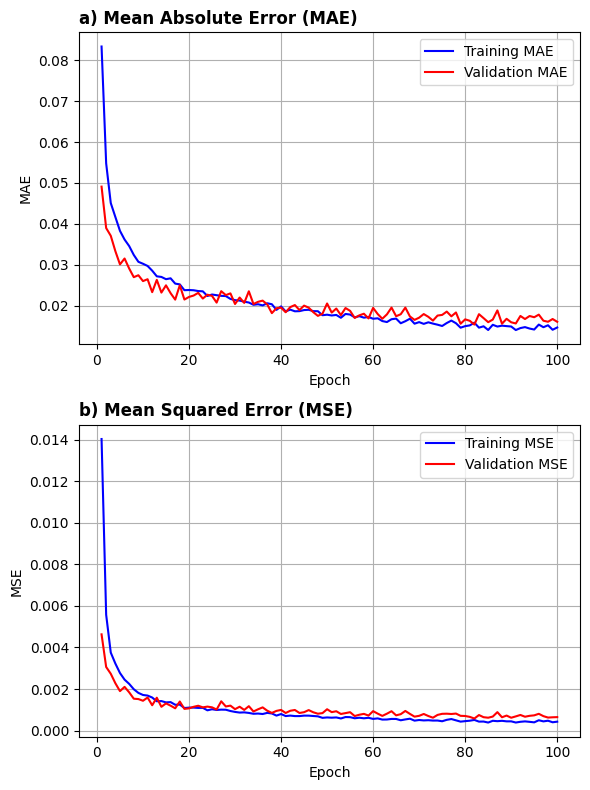

In [ ]:
# Evaluate the final model on the test set
print("\n📊 Evaluating Final Model on Test Data...")
test_loss, test_mae = final_birnn_model.evaluate(X_test_final_with_indices, y_test, verbose=0)

# Make predictions on the test set
y_pred_test = final_birnn_model.predict(X_test_final_with_indices)

# Calculate final test metrics
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Display test metrics
print("\n🎯 Final Model Performance on Test Data:")
print(f"Test MSE: {mse_test:.4f}")
print(f"Test MAE: {mae_test:.4f}")
print(f"Test R² Score: {r2_test:.4f}")

# Save the final model
final_birnn_model.save('final_birnn_regression_model.h5')

# Plot training history
import matplotlib.pyplot as plt

def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)

    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']
    val_mse = history.history['val_loss']

    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE')
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

# Plot final model training history
plot_training_validation_metrics(history_final)

# Test BiRNN

In [ ]:
# Load unseen data
df_unseen = pd.read_csv(
    'large_fires_data_v2_predictions.csv',
    names= [
        'point_id',
        'lat_dd',
        'long_dd',
        'Aspect',
        'Climatic water deficit',
        'Elevation',
        'Humidity',
        'LULC',
        'NDVI',
        'Evaptranspiration',
        'Precipitation',
        'Slope',
        'Soil moisture',
        'Shortwave radiation flux',
        'Maximum Temperature',
        'Wind speed',
        'dist_fores',
        'human_foot',
        'tree_speci',
        'pdsi'
    ],
    header= 0
)

# Replace -9999 with NaN
df_unseen.replace(-9999, np.nan, inplace=True)

# Fill missing values using forward fill, then backward fill
df_unseen.fillna(method='ffill', inplace=True)
df_unseen.fillna(method='bfill', inplace=True)


replace_values_LULC = {
    1: 'Urban_areas',
    2: 'Crop_land',
    3: 'Grass_land',
    4: 'Tree_covered',
    5: 'Shrub_covered',
    6: 'Herbaceous',
    8: 'Sparse_vegetation',
    9: 'Bare_soil',
    10: 'Snow',
    11: 'Water_bodies',
}

df_unseen['LULC'] = df_unseen['LULC'].replace(replace_values_LULC)
# Convert necessary columns to categorical
df_unseen = df_unseen.astype(
    {
        'LULC': 'category'
    }
)

# Define categorical, numerical, and additional columns
categorical_columns = ['LULC']
numerical_columns = [
    'Climatic water deficit', 'Elevation', 'Humidity', 'NDVI',
    'Evaptranspiration', 'Precipitation', 'Slope', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed'
]
additional_columns = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']  # Columns to retain

# Apply the trained encoder and scaler
X_unseen_encoded = pd.DataFrame(encoder.transform(df_unseen[categorical_columns]),
                                columns=encoder.get_feature_names_out(categorical_columns))
X_unseen_scaled = pd.DataFrame(scaler.transform(df_unseen[numerical_columns]), columns=numerical_columns)

# Concatenate encoded categorical and scaled numerical features
X_unseen_final = pd.concat([X_unseen_scaled.reset_index(drop=True), X_unseen_encoded.reset_index(drop=True)], axis=1)

# Save the processed unseen data to a CSV file
X_unseen_final.to_csv('unseen_data_preprocessed.csv', index=False)

# Display the first few rows of the processed data
X_unseen_final.head()


# Extract additional columns from the original unseen dataframe
X_unseen_additional = df_unseen[additional_columns].reset_index(drop=True)

# Concatenate processed numerical, encoded categorical, and additional columns
X_unseen_final = pd.concat([X_unseen_additional, X_unseen_scaled.reset_index(drop=True), X_unseen_encoded.reset_index(drop=True)], axis=1)

# Save the final processed unseen data to a CSV file
X_unseen_final.to_csv('unseen_data_preprocessed.csv', index=False)


# Define features to be removed
features_to_remove = [
    'Slope', 'LULC_Bare_soil', 'LULC_Grass_land', 'LULC_Herbaceous',
    'LULC_Shrub_covered', 'LULC_Snow', 'LULC_Sparse_vegetation',
    'LULC_Tree_covered', 'LULC_Urban_areas', 'LULC_Water_bodies',
    'LULC_Crop_land']

# Drop the selected features from the unseen dataset
X_unseen_final_selected = X_unseen_final.drop(columns=features_to_remove, errors='ignore')

# Save the final feature-selected unseen dataset to a CSV file
X_unseen_final_selected.to_csv('unseen_data_preprocessed_selected.csv', index=False)

# Display the first few rows of the final dataset
X_unseen_final_selected.head()

<ipython-input-101-d2f8a3ba88f5>:33: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_unseen.fillna(method='ffill', inplace=True)
<ipython-input-101-d2f8a3ba88f5>:34: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_unseen.fillna(method='bfill', inplace=True)


,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed
0,12493,48.383883,-123.961333,0.0,18.0,0.0,-1.644420,0.235890,-0.650606,3.606709,2.956919,-1.416099,5.165150,10.047394,0.578700,1.808995,-0.218442
1,12494,48.383883,-123.878000,0.0,18.0,0.0,-1.360750,0.501232,-0.650606,3.606709,2.956919,-1.256096,4.229343,9.200096,0.655071,1.959905,-0.263540
2,12495,48.383883,-123.794667,0.0,18.0,0.0,-1.257080,0.480461,-0.650606,3.606709,2.956919,-1.265900,4.089548,8.782554,0.628971,1.879290,-0.378766
3,12497,48.383883,-123.628000,0.0,18.0,30.0,-0.977667,0.840256,-0.650606,3.606709,3.513260,-1.135172,3.026936,7.599548,0.657577,1.923312,-0.365126
4,12498,48.383883,-123.544667,0.0,41.0,0.0,-0.797250,1.401187,-0.650606,3.590787,2.829750,-0.927897,1.739286,6.663895,0.703734,2.095714,-0.362959


In [ ]:
from tensorflow.keras.models import load_model
import tensorflow.keras.losses

# Load the trained BiRNN model
custom_objects = {
    "mse": tensorflow.keras.losses.MeanSquaredError()
}
final_birnn_model = load_model('final_birnn_regression_model.h5', custom_objects=custom_objects)

# Load the preprocessed unseen data
X_unseen_final_selected = pd.read_csv('unseen_data_preprocessed_selected.csv')

# Define features for prediction
features_for_prediction = [
    'Climatic water deficit', 'Elevation', 'Humidity',
    'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed'
]

# Extract only the required features
X_unseen_for_prediction = X_unseen_final_selected[features_for_prediction]

# Reshape for BiRNN (RNNs expect 3D input: (samples, timesteps, features))
X_unseen_for_prediction = X_unseen_for_prediction.values.reshape(
    (X_unseen_for_prediction.shape[0], X_unseen_for_prediction.shape[1], 1)
)

# Make predictions
predictions = final_birnn_model.predict(X_unseen_for_prediction)

# Rename the target feature and format to 4 decimal places
X_unseen_final_selected['wildfire_proba'] = predictions
X_unseen_final_selected['wildfire_proba'] = X_unseen_final_selected['wildfire_proba'].round(4)

# Keep only reference columns and the target feature
additional_features = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']
final_unseen_results = X_unseen_final_selected[additional_features + ['wildfire_proba']]

# Save the results
final_unseen_results.to_csv('unseen_data_with_wildfire_proba_BiRNN.csv', index=False)

# Display first few rows of predictions
final_unseen_results.head()


5172/5172 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step


,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,wildfire_proba
0,12493,48.383883,-123.961333,0.0,18.0,0.0,-1.644420,0.1502
1,12494,48.383883,-123.878000,0.0,18.0,0.0,-1.360750,0.1236
2,12495,48.383883,-123.794667,0.0,18.0,0.0,-1.257080,0.1396
3,12497,48.383883,-123.628000,0.0,18.0,30.0,-0.977667,0.0827
4,12498,48.383883,-123.544667,0.0,41.0,0.0,-0.797250,0.0529


# RNN model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define a function to create the RNN model
def create_rnn(input_shape, dropout_rate=0.1):
    model = Sequential([
        SimpleRNN(128, activation='relu', return_sequences=True, input_shape=(input_shape, 1)),
        Dropout(dropout_rate),
        SimpleRNN(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_rnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Store cross-validation results
cv_results = []

# Perform 10-Fold Spatial Cross-Validation
for fold_split in spatial_cv_splits:
    fold = fold_split["fold"]
    X_train_fold = fold_split["X_train"]
    y_train_fold = fold_split["y_train"]
    X_val_fold = fold_split["X_val"]
    y_val_fold = fold_split["y_val"]

    print(f"\n🔹 Training Fold {fold} (Train on 9 folds, Validate on 1 fold)...")

    # Reshape input data for RNN (RNNs expect 3D input: (samples, timesteps, features))
    X_train_fold = X_train_fold.values.reshape((X_train_fold.shape[0], X_train_fold.shape[1], 1))
    X_val_fold = X_val_fold.values.reshape((X_val_fold.shape[0], X_val_fold.shape[1], 1))

    # Define input shape
    input_shape = X_train_fold.shape[1]

    # Create and compile the RNN model
    rnn_model = create_rnn(input_shape)
    rnn_model = compile_rnn(rnn_model)

    # Train the model
    history = rnn_model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        verbose=1
    )

    # Evaluate the model on the validation set
    val_loss, val_mae = rnn_model.evaluate(X_val_fold, y_val_fold, verbose=0)

    # Make predictions on the validation set
    y_pred_val = rnn_model.predict(X_val_fold)

    # Calculate regression metrics
    mse = mean_squared_error(y_val_fold, y_pred_val)
    mae = mean_absolute_error(y_val_fold, y_pred_val)
    r2 = r2_score(y_val_fold, y_pred_val)

    # Store results
    cv_results.append({
        "Fold": fold,
        "Validation MSE": mse,
        "Validation MAE": mae,
        "Validation R²": r2
    })

    print(f"✅ Fold {fold} Results: MSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

# Convert results to DataFrame and display
cv_results_df = pd.DataFrame(cv_results)
print("\n📊 Cross-Validation Results:\n", cv_results_df)



🔹 Training Fold 0 (Train on 9 folds, Validate on 1 fold)...
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


189/189 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0264 - mae: 0.1114 - val_loss: 0.0537 - val_mae: 0.1714
Epoch 2/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0059 - mae: 0.0566 - val_loss: 0.0437 - val_mae: 0.1543
Epoch 3/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0045 - mae: 0.0488 - val_loss: 0.0427 - val_mae: 0.1550
Epoch 4/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0036 - mae: 0.0434 - val_loss: 0.0553 - val_mae: 0.1785
Epoch 5/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0032 - mae: 0.0407 - val_loss: 0.0512 - val_mae: 0.1713
Epoch 6/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0026 - mae: 0.0367 - val_loss: 0.0478 - val_mae: 0.1670
Epoch 7/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0023 - mae: 0.0348 - val_loss: 0.0486 - val_mae: 0.1632
Epoch 8/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0021 - mae: 0.0331 - val_loss: 0.0477 - val_mae: 0.1652
Epoch 9/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/ste

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


195/195 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0258 - mae: 0.1120 - val_loss: 0.0312 - val_mae: 0.1358
Epoch 2/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0069 - mae: 0.0603 - val_loss: 0.0390 - val_mae: 0.1390
Epoch 3/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0050 - mae: 0.0520 - val_loss: 0.0246 - val_mae: 0.1132
Epoch 4/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0042 - mae: 0.0473 - val_loss: 0.0274 - val_mae: 0.1221
Epoch 5/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0034 - mae: 0.0422 - val_loss: 0.0326 - val_mae: 0.1335
Epoch 6/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0029 - mae: 0.0390 - val_loss: 0.0246 - val_mae: 0.1154
Epoch 7/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0026 - mae: 0.0370 - val_loss: 0.0260 - val_mae: 0.1187
Epoch 8/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0026 - mae: 0.0367 - val_loss: 0.0231 - val_mae: 0.1188
Epoch 9/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/ste

...

198/198 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0406 - mae: 0.1389 - val_loss: 0.0035 - val_mae: 0.0516
Epoch 2/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0087 - mae: 0.0692 - val_loss: 0.0013 - val_mae: 0.0299
Epoch 3/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0053 - mae: 0.0549 - val_loss: 6.6227e-04 - val_mae: 0.0208
Epoch 4/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0042 - mae: 0.0482 - val_loss: 5.2239e-04 - val_mae: 0.0189
Epoch 5/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0039 - mae: 0.0453 - val_loss: 0.0013 - val_mae: 0.0308
Epoch 6/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0033 - mae: 0.0418 - val_loss: 9.5760e-04 - val_mae: 0.0231
Epoch 7/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0029 - mae: 0.0403 - val_loss: 0.0015 - val_mae: 0.0347
Epoch 8/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0026 - mae: 0.0376 - val_loss: 2.1043e-04 - val_mae: 0.0110
Epoch 9/100
198/198 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


189/189 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0230 - mae: 0.1068 - val_loss: 0.0264 - val_mae: 0.1209
Epoch 2/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0062 - mae: 0.0569 - val_loss: 0.0132 - val_mae: 0.0934
Epoch 3/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0043 - mae: 0.0477 - val_loss: 0.0116 - val_mae: 0.0827
Epoch 4/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0033 - mae: 0.0418 - val_loss: 0.0117 - val_mae: 0.0823
Epoch 5/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0031 - mae: 0.0397 - val_loss: 0.0124 - val_mae: 0.0878
Epoch 6/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0024 - mae: 0.0348 - val_loss: 0.0122 - val_mae: 0.0828
Epoch 7/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0021 - mae: 0.0332 - val_loss: 0.0109 - val_mae: 0.0820
Epoch 8/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0021 - mae: 0.0328 - val_loss: 0.0112 - val_mae: 0.0789
Epoch 9/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/ste

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0298 - mae: 0.1172 - val_loss: 0.0132 - val_mae: 0.0880
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0064 - mae: 0.0584 - val_loss: 0.0094 - val_mae: 0.0736
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0050 - mae: 0.0521 - val_loss: 0.0099 - val_mae: 0.0742
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0041 - mae: 0.0474 - val_loss: 0.0099 - val_mae: 0.0794
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0034 - mae: 0.0424 - val_loss: 0.0086 - val_mae: 0.0740
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0029 - mae: 0.0388 - val_loss: 0.0096 - val_mae: 0.0743
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0026 - mae: 0.0369 - val_loss: 0.0064 - val_mae: 0.0638
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0025 - mae: 0.0371 - val_loss: 0.0090 - val_mae: 0.0727
Epoch 9/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/ste

In [ ]:
print("\n🚀 Training Final RNN Model on Full Training Data...")

# Load full training data
X_train_full = X_train_final_with_indices.drop(columns=["spatial_fold"])
y_train_full = y_train

# Reshape for RNN
X_train_full = X_train_full.values.reshape((X_train_full.shape[0], X_train_full.shape[1], 1))

# Define and compile the final RNN model
input_shape = X_train_full.shape[1]
final_rnn_model = create_rnn(input_shape)
final_rnn_model = compile_rnn(final_rnn_model)

history_final = final_rnn_model.fit(
    X_train_full, y_train_full,
    validation_data=(X_val_final_with_indices, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Save the trained model
final_rnn_model.save('final_rnn_regression_model.h5')



🚀 Training Final RNN Model on Full Training Data...
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


212/212 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0268 - mae: 0.1139 - val_loss: 0.0057 - val_mae: 0.0539
Epoch 2/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0072 - mae: 0.0614 - val_loss: 0.0039 - val_mae: 0.0450
Epoch 3/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0052 - mae: 0.0527 - val_loss: 0.0030 - val_mae: 0.0392
Epoch 4/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0040 - mae: 0.0461 - val_loss: 0.0038 - val_mae: 0.0431
Epoch 5/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0034 - mae: 0.0422 - val_loss: 0.0024 - val_mae: 0.0353
Epoch 6/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0029 - mae: 0.0394 - val_loss: 0.0024 - val_mae: 0.0366
Epoch 7/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0027 - mae: 0.0381 - val_loss: 0.0023 - val_mae: 0.0344
Epoch 8/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0023 - mae: 0.0349 - val_loss: 0.0018 - val_mae: 0.0308
Epoch 9/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/ste

In [ ]:
print("\n📊 Evaluating Final Model on Test Data...")
test_loss, test_mae = final_rnn_model.evaluate(X_test_final_with_indices, y_test, verbose=0)

# Make predictions on the test set
y_pred_test = final_rnn_model.predict(X_test_final_with_indices)

# Calculate final test metrics
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Display test metrics
print("\n🎯 Final Model Performance on Test Data:")
print(f"Test MSE: {mse_test:.4f}")
print(f"Test MAE: {mae_test:.4f}")
print(f"Test R² Score: {r2_test:.4f}")

# Save the final model
final_rnn_model.save('final_rnn_regression_model.h5')



📊 Evaluating Final Model on Test Data...
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step



🎯 Final Model Performance on Test Data:
Test MSE: 0.0009
Test MAE: 0.0199
Test R² Score: 0.9805


In [ ]:
from tensorflow.keras.models import load_model
import tensorflow.keras.losses

# Load the trained RNN model
custom_objects = {
    "mse": tensorflow.keras.losses.MeanSquaredError()
}
final_rnn_model = load_model('final_rnn_regression_model.h5', custom_objects=custom_objects)

# Load the preprocessed unseen data
X_unseen_final_selected = pd.read_csv('unseen_data_preprocessed_selected.csv')

# Define features for prediction
features_for_prediction = [
    'Climatic water deficit', 'Elevation', 'Humidity',
    'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed'
]

# Extract only the required features
X_unseen_for_prediction = X_unseen_final_selected[features_for_prediction]

# Reshape for RNN (RNNs expect 3D input: (samples, timesteps, features))
X_unseen_for_prediction = X_unseen_for_prediction.values.reshape(
    (X_unseen_for_prediction.shape[0], X_unseen_for_prediction.shape[1], 1)
)

# Make predictions
predictions = final_rnn_model.predict(X_unseen_for_prediction)

# Rename the target feature and format to 4 decimal places
X_unseen_final_selected['wildfire_proba'] = predictions
X_unseen_final_selected['wildfire_proba'] = X_unseen_final_selected['wildfire_proba'].round(4)

# Keep only reference columns and the target feature
additional_features = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']
final_unseen_results = X_unseen_final_selected[additional_features + ['wildfire_proba']]

# Save the results
final_unseen_results.to_csv('unseen_data_with_wildfire_proba_RNN.csv', index=False)

# Display first few rows of predictions
print(final_unseen_results.head())


5172/5172 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step
   point_id     lat_dd     long_dd  dist_fores  human_foot  tree_speci  \
0     12493  48.383883 -123.961333         0.0        18.0         0.0   
1     12494  48.383883 -123.878000         0.0        18.0         0.0   
2     12495  48.383883 -123.794667         0.0        18.0         0.0   
3     12497  48.383883 -123.628000         0.0        18.0        30.0   
4     12498  48.383883 -123.544667         0.0        41.0         0.0   

       pdsi  wildfire_proba  
0 -1.644420          0.0849  
1 -1.360750          0.0859  
2 -1.257080          0.1003  
3 -0.977667          0.1205  
4 -0.797250          0.1410  


# LSTM

## Train the LSTM model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define a function to create the LSTM model
def create_lstm(input_shape, dropout_rate=0.1):
    model = Sequential([
        LSTM(128, activation='relu', return_sequences=True, input_shape=(input_shape, 1)),
        Dropout(dropout_rate),
        LSTM(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_lstm(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Store cross-validation results
cv_results = []

# Perform 10-Fold Spatial Cross-Validation
for fold_split in spatial_cv_splits:
    fold = fold_split["fold"]
    X_train_fold = fold_split["X_train"]
    y_train_fold = fold_split["y_train"]
    X_val_fold = fold_split["X_val"]
    y_val_fold = fold_split["y_val"]

    print(f"\n🔹 Training Fold {fold} (Train on 9 folds, Validate on 1 fold)...")

    # Reshape input data for LSTM (LSTMs expect 3D input: (samples, timesteps, features))
    X_train_fold = X_train_fold.values.reshape((X_train_fold.shape[0], X_train_fold.shape[1], 1))
    X_val_fold = X_val_fold.values.reshape((X_val_fold.shape[0], X_val_fold.shape[1], 1))

    # Define input shape
    input_shape = X_train_fold.shape[1]

    # Create and compile the LSTM model
    lstm_model = create_lstm(input_shape)
    lstm_model = compile_lstm(lstm_model)

    # Train the model
    history = lstm_model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        verbose=1
    )

    # Evaluate the model on the validation set
    val_loss, val_mae = lstm_model.evaluate(X_val_fold, y_val_fold, verbose=0)

    # Make predictions on the validation set
    y_pred_val = lstm_model.predict(X_val_fold)

    # Calculate regression metrics
    mse = mean_squared_error(y_val_fold, y_pred_val)
    mae = mean_absolute_error(y_val_fold, y_pred_val)
    r2 = r2_score(y_val_fold, y_pred_val)

    # Store results
    cv_results.append({
        "Fold": fold,
        "Validation MSE": mse,
        "Validation MAE": mae,
        "Validation R²": r2
    })

    print(f"✅ Fold {fold} Results: MSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

# Convert results to DataFrame and display
cv_results_df = pd.DataFrame(cv_results)
print("\n📊 Cross-Validation Results:\n", cv_results_df)



🔹 Training Fold 0 (Train on 9 folds, Validate on 1 fold)...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.0407 - mae: 0.1418 - val_loss: 0.0544 - val_mae: 0.1668
Epoch 2/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - loss: 0.0144 - mae: 0.0829 - val_loss: 0.0533 - val_mae: 0.1665
Epoch 3/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - loss: 0.0130 - mae: 0.0785 - val_loss: 0.0305 - val_mae: 0.1374
Epoch 4/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: 0.0127 - mae: 0.0775 - val_loss: 0.0421 - val_mae: 0.1495
Epoch 5/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - loss: 0.0114 - mae: 0.0728 - val_loss: 0.0435 - val_mae: 0.1532
Epoch 6/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 0.0101 - mae: 0.0676 - val_loss: 0.0355 - val_mae: 0.1393
Epoch 7/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0090 - mae: 0.0649 - val_loss: 0.0288 - val_mae: 0.1217
Epoch 8/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - loss: 0.0086 - mae: 0.0632 - val_loss: 0.0322 - val_mae: 0.1333
Epoch 9/100
189/189 ━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


195/195 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0387 - mae: 0.1431 - val_loss: 0.0140 - val_mae: 0.0974
Epoch 2/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0184 - mae: 0.0943 - val_loss: 0.0144 - val_mae: 0.1024
Epoch 3/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.0125 - mae: 0.0781 - val_loss: 0.0210 - val_mae: 0.1201
Epoch 4/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0104 - mae: 0.0698 - val_loss: 0.0274 - val_mae: 0.1336
Epoch 5/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0096 - mae: 0.0687 - val_loss: 0.0163 - val_mae: 0.1013
Epoch 6/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - loss: 0.0091 - mae: 0.0655 - val_loss: 0.0143 - val_mae: 0.0954
Epoch 7/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0087 - mae: 0.0647 - val_loss: 0.0280 - val_mae: 0.1273
Epoch 8/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0068 - mae: 0.0576 - val_loss: 0.0414 - val_mae: 0.1683
Epoch 9/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/s

...

198/198 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - loss: 0.0414 - mae: 0.1497 - val_loss: 0.0016 - val_mae: 0.0337
Epoch 2/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.0188 - mae: 0.0979 - val_loss: 0.0014 - val_mae: 0.0313
Epoch 3/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.0145 - mae: 0.0875 - val_loss: 0.0014 - val_mae: 0.0360
Epoch 4/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.0133 - mae: 0.0819 - val_loss: 8.3255e-05 - val_mae: 0.0070
Epoch 5/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.0120 - mae: 0.0780 - val_loss: 4.6120e-04 - val_mae: 0.0202
Epoch 6/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.0105 - mae: 0.0731 - val_loss: 3.6371e-04 - val_mae: 0.0168
Epoch 7/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.0097 - mae: 0.0703 - val_loss: 0.0012 - val_mae: 0.0292
Epoch 8/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.0086 - mae: 0.0659 - val_loss: 0.0016 - val_mae: 0.0339
Epoch 9/100
198/198 ━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


189/189 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - loss: 0.0321 - mae: 0.1265 - val_loss: 0.0726 - val_mae: 0.2397
Epoch 2/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.0169 - mae: 0.0904 - val_loss: 0.0570 - val_mae: 0.2075
Epoch 3/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - loss: 0.0122 - mae: 0.0764 - val_loss: 0.0487 - val_mae: 0.1901
Epoch 4/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - loss: 0.0107 - mae: 0.0723 - val_loss: 0.0791 - val_mae: 0.2410
Epoch 5/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0108 - mae: 0.0718 - val_loss: 0.0281 - val_mae: 0.1410
Epoch 6/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 0.0093 - mae: 0.0660 - val_loss: 0.0252 - val_mae: 0.1326
Epoch 7/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 0.0086 - mae: 0.0646 - val_loss: 0.0234 - val_mae: 0.1251
Epoch 8/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.0079 - mae: 0.0613 - val_loss: 0.0313 - val_mae: 0.1481
Epoch 9/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 7s 37

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


192/192 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - loss: 0.0380 - mae: 0.1379 - val_loss: 0.0165 - val_mae: 0.0966
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - loss: 0.0177 - mae: 0.0930 - val_loss: 0.0207 - val_mae: 0.1017
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0141 - mae: 0.0817 - val_loss: 0.0157 - val_mae: 0.0953
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0114 - mae: 0.0734 - val_loss: 0.0136 - val_mae: 0.0866
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0114 - mae: 0.0727 - val_loss: 0.0137 - val_mae: 0.0899
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: 0.0112 - mae: 0.0716 - val_loss: 0.0110 - val_mae: 0.0796
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 0.0098 - mae: 0.0668 - val_loss: 0.0132 - val_mae: 0.0846
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - loss: 0.0083 - mae: 0.0616 - val_loss: 0.0135 - val_mae: 0.0849
Epoch 9/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/st

## Train the final LSTM model

In [ ]:
print("\n🚀 Training Final LSTM Model on Full Training Data...")

# Load full training data
X_train_full = X_train_final_with_indices.drop(columns=["spatial_fold"])
y_train_full = y_train

# Reshape for LSTM
X_train_full = X_train_full.values.reshape((X_train_full.shape[0], X_train_full.shape[1], 1))

# Define and compile the final LSTM model
input_shape = X_train_full.shape[1]
final_lstm_model = create_lstm(input_shape)
final_lstm_model = compile_lstm(final_lstm_model)

history_final = final_lstm_model.fit(
    X_train_full, y_train_full,
    validation_data=(X_val_final_with_indices, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Save the trained model
final_lstm_model.save('final_lstm_regression_model.h5')



🚀 Training Final LSTM Model on Full Training Data...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - loss: 0.0368 - mae: 0.1366 - val_loss: 0.0155 - val_mae: 0.0855
Epoch 2/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0172 - mae: 0.0930 - val_loss: 0.0142 - val_mae: 0.0841
Epoch 3/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.0145 - mae: 0.0841 - val_loss: 0.0113 - val_mae: 0.0765
Epoch 4/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 0.0109 - mae: 0.0737 - val_loss: 0.0105 - val_mae: 0.0730
Epoch 5/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.0109 - mae: 0.0725 - val_loss: 0.0091 - val_mae: 0.0632
Epoch 6/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 0.0096 - mae: 0.0680 - val_loss: 0.0077 - val_mae: 0.0608
Epoch 7/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0088 - mae: 0.0653 - val_loss: 0.0075 - val_mae: 0.0622
Epoch 8/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.0078 - mae: 0.0621 - val_loss: 0.0078 - val_mae: 0.0615
Epoch 9/100
212/212 ━━━━━━━━━━━━━━━━━━

## Evaluate the Final model on the test set

In [ ]:
print("\n📊 Evaluating Final Model on Test Data...")
test_loss, test_mae = final_lstm_model.evaluate(X_test_final_with_indices, y_test, verbose=0)

# Make predictions on the test set
y_pred_test = final_lstm_model.predict(X_test_final_with_indices)

# Calculate final test metrics
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Display test metrics
print("\n🎯 Final Model Performance on Test Data:")
print(f"Test MSE: {mse_test:.4f}")
print(f"Test MAE: {mae_test:.4f}")
print(f"Test R² Score: {r2_test:.4f}")

# Save the final model
final_lstm_model.save('final_lstm_regression_model.h5')



📊 Evaluating Final Model on Test Data...
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step



🎯 Final Model Performance on Test Data:
Test MSE: 0.0008
Test MAE: 0.0197
Test R² Score: 0.9826


## Predict Wildfire Probability on unseen data

In [ ]:
from tensorflow.keras.models import load_model
import tensorflow.keras.losses

# Load the trained LSTM model
custom_objects = {
    "mse": tensorflow.keras.losses.MeanSquaredError()
}
final_lstm_model = load_model('final_lstm_regression_model.h5', custom_objects=custom_objects)

# Load the preprocessed unseen data
X_unseen_final_selected = pd.read_csv('unseen_data_preprocessed_selected.csv')

# Define features for prediction
features_for_prediction = [
    'Climatic water deficit', 'Elevation', 'Humidity',
    'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed'
]

# Extract only the required features
X_unseen_for_prediction = X_unseen_final_selected[features_for_prediction]

# Reshape for LSTM (LSTMs expect 3D input: (samples, timesteps, features))
X_unseen_for_prediction = X_unseen_for_prediction.values.reshape(
    (X_unseen_for_prediction.shape[0], X_unseen_for_prediction.shape[1], 1)
)

# Make predictions
predictions = final_lstm_model.predict(X_unseen_for_prediction)

# Rename the target feature and format to 4 decimal places
X_unseen_final_selected['wildfire_proba'] = predictions
X_unseen_final_selected['wildfire_proba'] = X_unseen_final_selected['wildfire_proba'].round(4)

# Keep only reference columns and the target feature
additional_features = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']
final_unseen_results = X_unseen_final_selected[additional_features + ['wildfire_proba']]

# Save the results
final_unseen_results.to_csv('unseen_data_with_wildfire_proba_LSTM.csv', index=False)

# Display first few rows of predictions
final_unseen_results.head()

5172/5172 ━━━━━━━━━━━━━━━━━━━━ 66s 12ms/step


,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,wildfire_proba
0,12493,48.383883,-123.961333,0.0,18.0,0.0,-1.644420,0.0654
1,12494,48.383883,-123.878000,0.0,18.0,0.0,-1.360750,0.0642
2,12495,48.383883,-123.794667,0.0,18.0,0.0,-1.257080,0.0810
3,12497,48.383883,-123.628000,0.0,18.0,30.0,-0.977667,0.0850
4,12498,48.383883,-123.544667,0.0,41.0,0.0,-0.797250,0.1323


# Encoder-Decoder BiRNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Bidirectional, SimpleRNN, RepeatVector, TimeDistributed
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define a function to create the Encoder-Decoder BiRNN model
def create_encoder_decoder_birnn(input_shape, dropout_rate=0.1):
    # Encoder
    encoder_inputs = Input(shape=(input_shape, 1))
    encoder = Bidirectional(SimpleRNN(128, activation='relu', return_sequences=False))(encoder_inputs)
    encoder = Dropout(dropout_rate)(encoder)

    # Repeat the context vector to match output shape
    decoder_inputs = RepeatVector(1)(encoder)  # 1 means we predict one target value

    # Decoder
    decoder = Bidirectional(SimpleRNN(64, activation='relu', return_sequences=True))(decoder_inputs)
    decoder = Dropout(dropout_rate)(decoder)

    # Final output layer
    outputs = TimeDistributed(Dense(1, activation='linear'))(decoder)

    # Define model
    model = Model(inputs=encoder_inputs, outputs=outputs)

    return model

# Compile the model
def compile_encoder_decoder_birnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Store cross-validation results
cv_results = []

# Perform 10-Fold Spatial Cross-Validation
for fold_split in spatial_cv_splits:
    fold = fold_split["fold"]
    X_train_fold = fold_split["X_train"]
    y_train_fold = fold_split["y_train"]
    X_val_fold = fold_split["X_val"]
    y_val_fold = fold_split["y_val"]

    print(f"\n🔹 Training Fold {fold} (Train on 9 folds, Validate on 1 fold)...")

    # Reshape input data for Encoder-Decoder BiRNN (RNNs expect 3D input: (samples, timesteps, features))
    X_train_fold = X_train_fold.values.reshape((X_train_fold.shape[0], X_train_fold.shape[1], 1))
    X_val_fold = X_val_fold.values.reshape((X_val_fold.shape[0], X_val_fold.shape[1], 1))
    y_train_fold = y_train_fold.values.reshape((y_train_fold.shape[0], 1, 1))  # Target also needs to be reshaped
    y_val_fold = y_val_fold.values.reshape((y_val_fold.shape[0], 1, 1))

    # Define input shape
    input_shape = X_train_fold.shape[1]

    # Create and compile the Encoder-Decoder BiRNN model
    birnn_encoder_decoder_model = create_encoder_decoder_birnn(input_shape)
    birnn_encoder_decoder_model = compile_encoder_decoder_birnn(birnn_encoder_decoder_model)

    # Train the model
    history = birnn_encoder_decoder_model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        verbose=1
    )

    # Evaluate the model on the validation set
    val_loss, val_mae = birnn_encoder_decoder_model.evaluate(X_val_fold, y_val_fold, verbose=0)

    # Make predictions on the validation set
    y_pred_val = birnn_encoder_decoder_model.predict(X_val_fold).reshape(-1)

    # Calculate regression metrics
    mse = mean_squared_error(y_val_fold.reshape(-1), y_pred_val)
    mae = mean_absolute_error(y_val_fold.reshape(-1), y_pred_val)
    r2 = r2_score(y_val_fold.reshape(-1), y_pred_val)

    # Store results
    cv_results.append({
        "Fold": fold,
        "Validation MSE": mse,
        "Validation MAE": mae,
        "Validation R²": r2
    })

    print(f"✅ Fold {fold} Results: MSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

# Convert results to DataFrame and display
cv_results_df = pd.DataFrame(cv_results)
print("\n📊 Cross-Validation Results:\n", cv_results_df)



🔹 Training Fold 0 (Train on 9 folds, Validate on 1 fold)...
Epoch 1/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - loss: 0.0235 - mae: 0.1058 - val_loss: 0.0346 - val_mae: 0.1408
Epoch 2/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0051 - mae: 0.0526 - val_loss: 0.0377 - val_mae: 0.1459
Epoch 3/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0034 - mae: 0.0419 - val_loss: 0.0317 - val_mae: 0.1345
Epoch 4/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0026 - mae: 0.0374 - val_loss: 0.0387 - val_mae: 0.1517
Epoch 5/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0025 - mae: 0.0351 - val_loss: 0.0315 - val_mae: 0.1306
Epoch 6/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0022 - mae: 0.0341 - val_loss: 0.0344 - val_mae: 0.1411
Epoch 7/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0020 - mae: 0.0315 - val_loss: 0.0297 - val_mae: 0.1265
Epoch 8/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0018 - mae: 0.0298 - val_loss: 0.0

In [ ]:
print("\n🚀 Training Final Encoder-Decoder BiRNN Model on Full Training Data...")

# Load full training data
X_train_full = X_train_final_with_indices.drop(columns=["spatial_fold"])
y_train_full = y_train

# Reshape for Encoder-Decoder BiRNN
X_train_full = X_train_full.values.reshape((X_train_full.shape[0], X_train_full.shape[1], 1))
y_train_full = y_train_full.values.reshape((y_train_full.shape[0], 1, 1))  # Target also needs reshaping

# Define and compile the final model
input_shape = X_train_full.shape[1]
final_birnn_encoder_decoder_model = create_encoder_decoder_birnn(input_shape)
final_birnn_encoder_decoder_model = compile_encoder_decoder_birnn(final_birnn_encoder_decoder_model)

history_final = final_birnn_encoder_decoder_model.fit(
    X_train_full, y_train_full,
    validation_data=(X_val_final_with_indices.values.reshape((X_val_final_with_indices.shape[0], X_val_final_with_indices.shape[1], 1)),
                     y_val.values.reshape((y_val.shape[0], 1, 1))),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Save the trained model
final_birnn_encoder_decoder_model.save('final_encoder_decoder_birnn_model.h5')



🚀 Training Final Encoder-Decoder BiRNN Model on Full Training Data...
Epoch 1/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0273 - mae: 0.1158 - val_loss: 0.0042 - val_mae: 0.0469
Epoch 2/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0049 - mae: 0.0523 - val_loss: 0.0031 - val_mae: 0.0393
Epoch 3/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0037 - mae: 0.0450 - val_loss: 0.0025 - val_mae: 0.0350
Epoch 4/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0030 - mae: 0.0399 - val_loss: 0.0023 - val_mae: 0.0338
Epoch 5/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0026 - mae: 0.0367 - val_loss: 0.0022 - val_mae: 0.0327
Epoch 6/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0025 - mae: 0.0362 - val_loss: 0.0018 - val_mae: 0.0283
Epoch 7/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0022 - mae: 0.0336 - val_loss: 0.0018 - val_mae: 0.0295
Epoch 8/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0019 - mae: 0.0313 - val

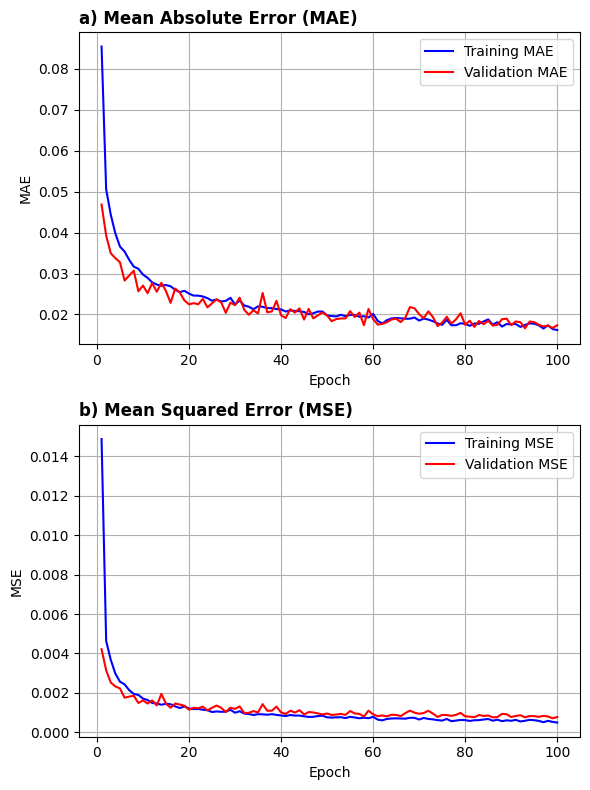

In [ ]:
import matplotlib.pyplot as plt

def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)

    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']
    val_mse = history.history['val_loss']

    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    # Plot MAE
    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].legend()
    axes[0].grid()

    # Plot MSE
    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE')
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

# Call the function to plot training and validation metrics
plot_training_validation_metrics(history_final)


In [ ]:
from tensorflow.keras.models import load_model
import tensorflow.keras.losses
import pandas as pd

# Load the trained Encoder-Decoder BiRNN model
custom_objects = {
    "mse": tensorflow.keras.losses.MeanSquaredError()
}
final_birnn_encoder_decoder_model = load_model('final_encoder_decoder_birnn_model.h5', custom_objects=custom_objects)

# Load the preprocessed unseen data
X_unseen_final_selected = pd.read_csv('unseen_data_preprocessed_selected.csv')

# Define features for prediction
features_for_prediction = [
    'Climatic water deficit', 'Elevation', 'Humidity',
    'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed'
]

# Extract only the required features
X_unseen_for_prediction = X_unseen_final_selected[features_for_prediction]

# Reshape for Encoder-Decoder BiRNN (3D input: (samples, timesteps, features))
X_unseen_for_prediction = X_unseen_for_prediction.values.reshape(
    (X_unseen_for_prediction.shape[0], X_unseen_for_prediction.shape[1], 1)
)

# Make predictions
predictions = final_birnn_encoder_decoder_model.predict(X_unseen_for_prediction).reshape(-1)

# Rename the target feature and format to 4 decimal places
X_unseen_final_selected['wildfire_proba'] = predictions
X_unseen_final_selected['wildfire_proba'] = X_unseen_final_selected['wildfire_proba'].round(4)

# Keep only reference columns and the target feature
additional_features = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']
final_unseen_results = X_unseen_final_selected[additional_features + ['wildfire_proba']]

# Save the results to a CSV file
final_unseen_results.to_csv('unseen_data_with_wildfire_proba_EncoderDecoderBiRNN.csv', index=False)

# Display first few rows of predictions
print(final_unseen_results.head())


5172/5172 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step
   point_id     lat_dd     long_dd  dist_fores  human_foot  tree_speci  \
0     12493  48.383883 -123.961333         0.0        18.0         0.0   
1     12494  48.383883 -123.878000         0.0        18.0         0.0   
2     12495  48.383883 -123.794667         0.0        18.0         0.0   
3     12497  48.383883 -123.628000         0.0        18.0        30.0   
4     12498  48.383883 -123.544667         0.0        41.0         0.0   

       pdsi  wildfire_proba  
0 -1.644420          0.0766  
1 -1.360750          0.0677  
2 -1.257080          0.0686  
3 -0.977667          0.0544  
4 -0.797250          0.0708  


# CatBoost



*   Steps for Implementing CatBoost
* Train CatBoost on Spatial Cross-Validation
* Train Final CatBoost Model on Full Training Data
* Predict Wildfire Probability on Unseen Data
* Save and Evaluate Results



In [52]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 4.9 MB/s eta 0:00:00


In [64]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Store cross-validation results
cv_results = []

# Perform 10-Fold Spatial Cross-Validation
for fold_split in spatial_cv_splits:
    fold = fold_split["fold"]
    X_train_fold = fold_split["X_train"]
    y_train_fold = fold_split["y_train"]
    X_val_fold = fold_split["X_val"]
    y_val_fold = fold_split["y_val"]

    print(f"\n🔹 Training Fold {fold} (Train on 9 folds, Validate on 1 fold)...")

    # Define CatBoost Model
    catboost_model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=8,
        loss_function='RMSE',
        random_seed=42,
        verbose=200
    )

    # Train model
    catboost_model.fit(X_train_fold, y_train_fold, eval_set=(X_val_fold, y_val_fold), early_stopping_rounds=100)

    # Make predictions on the validation set
    y_pred_val = catboost_model.predict(X_val_fold)

    # Calculate regression metrics
    mse = mean_squared_error(y_val_fold, y_pred_val)
    mae = mean_absolute_error(y_val_fold, y_pred_val)
    r2 = r2_score(y_val_fold, y_pred_val)

    # Store results
    cv_results.append({
        "Fold": fold,
        "Validation MSE": mse,
        "Validation MAE": mae,
        "Validation R²": r2
    })

    print(f"✅ Fold {fold} Results: MSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

# Convert results to DataFrame and display
cv_results_df = pd.DataFrame(cv_results)
print("\n📊 Cross-Validation Results:\n", cv_results_df)



🔹 Training Fold 0 (Train on 9 folds, Validate on 1 fold)...
0:	learn: 0.1963224	test: 0.2256557	best: 0.2256557 (0)	total: 58.6ms	remaining: 58.5s
200:	learn: 0.0326297	test: 0.1534886	best: 0.1534014 (196)	total: 2.1s	remaining: 8.34s
400:	learn: 0.0220375	test: 0.1497822	best: 0.1497395 (372)	total: 3.87s	remaining: 5.79s
600:	learn: 0.0171208	test: 0.1488852	best: 0.1486919 (590)	total: 5.68s	remaining: 3.77s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.1486919005
bestIteration = 590

Shrink model to first 591 iterations.
✅ Fold 0 Results: MSE=0.0221, MAE=0.1091, R²=0.2215

🔹 Training Fold 1 (Train on 9 folds, Validate on 1 fold)...
0:	learn: 0.2036754	test: 0.1412566	best: 0.1412566 (0)	total: 25.1ms	remaining: 25.1s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.1412566226
bestIteration = 0

Shrink model to first 1 iterations.
✅ Fold 1 Results: MSE=0.0200, MAE=0.1287, R²=-4.2256

🔹 Training Fold 2 (Train on 9 folds, Validate on 1 fold

In [65]:
print("\n🚀 Training Final CatBoost Model on Full Training Data...")

# Load full training data
X_train_full = X_train_final_with_indices.drop(columns=["spatial_fold"])
y_train_full = y_train

# Define and train the final CatBoost model
final_catboost_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=200
)

final_catboost_model.fit(X_train_full, y_train_full)

# Save the trained model
final_catboost_model.save_model('final_catboost_regression_model.cbm')



🚀 Training Final CatBoost Model on Full Training Data...
0:	learn: 0.1991063	total: 22.6ms	remaining: 22.6s
200:	learn: 0.0358067	total: 2.55s	remaining: 10.1s
400:	learn: 0.0247687	total: 4.34s	remaining: 6.49s
600:	learn: 0.0195193	total: 6.15s	remaining: 4.08s
800:	learn: 0.0162855	total: 7.95s	remaining: 1.97s
999:	learn: 0.0141317	total: 9.75s	remaining: 0us


In [66]:
# Load preprocessed unseen data
X_unseen_final_selected = pd.read_csv('unseen_data_preprocessed_selected.csv')

# Define features for prediction
features_for_prediction = [
    'Climatic water deficit', 'Elevation', 'Humidity',
    'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed'
]

# Extract only the required features
X_unseen_for_prediction = X_unseen_final_selected[features_for_prediction]

# Load the trained CatBoost model
final_catboost_model = CatBoostRegressor()
final_catboost_model.load_model('final_catboost_regression_model.cbm')

# Make predictions
predictions = final_catboost_model.predict(X_unseen_for_prediction)

# Rename the target feature and format to 4 decimal places
X_unseen_final_selected['wildfire_proba'] = predictions.round(4)

# Keep only reference columns and the target feature
additional_features = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']
final_unseen_results = X_unseen_final_selected[additional_features + ['wildfire_proba']]

# Save the results to a CSV file
final_unseen_results.to_csv('unseen_data_with_wildfire_proba_CatBoost.csv', index=False)

# Display first few rows of predictions
print(final_unseen_results.head())


   point_id     lat_dd     long_dd  dist_fores  human_foot  tree_speci  \
0     12493  48.383883 -123.961333         0.0        18.0         0.0   
1     12494  48.383883 -123.878000         0.0        18.0         0.0   
2     12495  48.383883 -123.794667         0.0        18.0         0.0   
3     12497  48.383883 -123.628000         0.0        18.0        30.0   
4     12498  48.383883 -123.544667         0.0        41.0         0.0   

       pdsi  wildfire_proba  
0 -1.644420          0.1215  
1 -1.360750          0.1472  
2 -1.257080          0.1421  
3 -0.977667          0.1815  
4 -0.797250          0.2093  
